# Tutorials to use

https://www.youtube.com/watch?v=wIvxFEMQVwg - differential expressin python with pyDESeq2, details GSEA as well. 


In [1]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
adata

AnnData object with n_obs × n_vars = 193025 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter'
    var: 'gene_ids', 'feature_types', 'genome', 'me

In [2]:
#only considering dorsal epi/dermis
adata = adata[adata.obs['compartment'].str.contains('orsal')]
adata.obs.compartment.unique()

['dorsal_dermis', 'dorsal_epidermis']
Categories (2, object): ['dorsal_dermis', 'dorsal_epidermis']

# Is there a difference in YAP1 expression between Ctrl and treatment samples?
#### I will do this as a bulk difference, then split by sex as well

## making bulk objects for various conditions

In [3]:
#bulk
import decoupler as dc

adata_epi = adata[adata.obs['compartment'].str.contains('_epidermis')].copy()
adata_derm = adata[adata.obs['compartment'].str.contains('_dermis')].copy()

#convert sc object to pseudobulk
big_bulk = dc.pp.pseudobulk(
    adata,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)

big_bulk_epidermis = dc.pp.pseudobulk(
    adata_epi,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)

big_bulk_dermis = dc.pp.pseudobulk(
    adata_derm,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)

#CELLTYPE bulk

#convert sc object to pseudobulk
celltype_bulk = dc.pp.pseudobulk(
    adata,
    sample_col = 'batch_key', #defines replicates
    groups_col = 'celltype_assignments', #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)

celltype_bulk_epidermis = dc.pp.pseudobulk(
    adata_epi,
    sample_col = 'batch_key', #defines replicates
    groups_col = 'celltype_assignments', #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)

celltype_bulk_dermis = dc.pp.pseudobulk(
    adata_derm,
    sample_col = 'batch_key', #defines replicates
    groups_col = 'celltype_assignments', #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)


d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def isolate_sex(adata, sex_str):
    bdata = adata[adata.obs.replicate.str.contains(sex_str)].copy()
    return bdata

bulk_objects = {'big_bulk':big_bulk, 'big_bulk_epidermis':big_bulk_epidermis, 'big_bulk_dermis':big_bulk_dermis, 
                'celltype_bulk':celltype_bulk, 'celltype_bulk_epidermis':celltype_bulk_epidermis, 'celltype_bulk_dermis':celltype_bulk_dermis,}

bulk_subtypes = {}
for name, obj in bulk_objects.items():
    bulk_subtypes[name] = obj
    for sex in ['F', 'M']:
        bulk_subtypes[f'{name}_{sex}'] = isolate_sex(obj, sex)



for name, obj in bulk_subtypes.items():
    print(name)
    print(obj)

big_bulk
AnnData object with n_obs × n_vars = 30 × 5056
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression'
    layers: 'psbulk_props'
big_bulk_F
AnnData object with n_obs × n_vars = 15 × 5056
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression'
    layers: 'psbulk_props'
big_bulk_M
AnnData object with n_obs × n_vars = 15 × 5056
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts

In [5]:
#generate individual adatas for celltypes
celltypes_bulk_split = {}

for name, object in bulk_subtypes.items():
    if 'celltype' in name:
        for type in object.obs.celltype_assignments.unique():
            celltypes_bulk_split[f'{type}_{name}'] = object[object.obs['celltype_assignments'] == type].copy()

celltypes_bulk_split

{'M2-like_macrophage_celltype_bulk': AnnData object with n_obs × n_vars = 30 × 5056
     obs: 'batch_key', 'celltype_assignments', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'psbulk_cells', 'psbulk_counts'
     var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression'
     layers: 'psbulk_props',
 'activated_basal_KC_celltype_bulk': AnnData object with n_obs × n_vars = 30 × 5056
     obs: 'batch_key', 'celltype_assignments', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'psbulk_cells', 'psbulk_counts'
     var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression'
     layers: 'psbulk_props',
 'activated_intermediate_basal_suprabasal_KC_celltype_bulk': AnnData objec

## Running DESEQ2 on the objects

In [5]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd
import numpy as np
import seaborn as sns
import gseapy as gp
from gseapy import gseaplot

In [9]:
from pathlib import Path
results_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\DESEQ_bulk_D3_D7_results")

In [7]:
#defining helper function for volcano plotting
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text   # pip install adjustText

def volcano_plot(df, title, save_dir):
    df = df.dropna(subset=['log2FoldChange', 'padj'])
    df['-log10padj'] = -np.log10(df['padj'])

    fc_thresh = 1.0
    padj_thresh = 0.05
    n_labels = 20  # number of top genes to label

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot all points
    colours = np.where(
        (df['padj'] < padj_thresh) & (df['log2FoldChange'] > fc_thresh), 'firebrick',
        np.where(
            (df['padj'] < padj_thresh) & (df['log2FoldChange'] < -fc_thresh), 'steelblue', 'lightgrey'
        )
    )
    ax.scatter(df['log2FoldChange'], df['-log10padj'], c=colours, alpha=0.6, s=15)

    # Label top genes by significance
    top_genes = df.nsmallest(n_labels, 'padj')
    texts = [
        ax.text(row['log2FoldChange'], row['-log10padj'], gene, fontsize=7)
        for gene, row in top_genes.iterrows()
    ]
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    ax.axhline(-np.log10(padj_thresh), color='black', linestyle='--', linewidth=0.8)
    ax.axvline(fc_thresh, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(-fc_thresh, color='black', linestyle='--', linewidth=0.8)

    ax.set_xlabel('log2 Fold Change')
    ax.set_ylabel('-log10 adjusted p-value')
    ax.set_title(title)
    
    save_path = save_dir / (title)
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()


In [8]:
#helper function for enrichment map plotting
from gseapy import enrichment_map
import networkx as nx

def enrichment_plot(pre_res, output_path):

    # return two dataframe
    nodes, edges = enrichment_map(pre_res.res2d)
    G = nx.from_pandas_edgelist(edges,
                            source='src_idx',
                            target='targ_idx',
                            edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])
    
    fig, ax = plt.subplots(figsize=(8, 8))

    # init node cooridnates
    pos=nx.layout.spiral_layout(G)

    # draw node
    nodelist = list(G.nodes())
    nodes_aligned = nodes.loc[nodelist]

    nx.draw_networkx_nodes(G,
                        pos=pos,
                        nodelist=nodelist,
                        cmap=plt.cm.RdYlBu,
                        node_color=list(nodes_aligned.NES),
                        node_size=list(nodes_aligned.Hits_ratio * 1000))

    nx.draw_networkx_labels(G,
                            pos=pos,
                            labels=nodes_aligned.Term.to_dict())
    # draw edge
    edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
    nx.draw_networkx_edges(G,
                        pos=pos,
                        width=list(map(lambda x: x*10, edge_weight)),
                        edge_color='#CDDBD4')
    
    ax.margins(0.3)  # increase margin to give more room for labels

    # after all draw calls, manually extend limits further
    x_values = [pos[n][0] for n in G.nodes()]
    y_values = [pos[n][1] for n in G.nodes()]

    pad = 0.3
    ax.set_xlim(min(x_values) - pad, max(x_values) + pad)
    ax.set_ylim(min(y_values) - pad, max(y_values) + pad)
    
    plt.savefig(output_path)
    plt.close()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_28044\1482143159.py:15: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts = bulk.X,
Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.85 seconds.

Fitting dispersion trend curve...
... done in 0.14 seconds.

Fitting MAP dispersions...
... done in 1.18 seconds.

Fitting LFCs...
... done in 0.82 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.50 seconds.



Log2 fold change & Wald test p-value: condition D7IMQ vs D3IMQ
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1cf      1.725998        1.147809  0.658008  1.744369  0.081095       NaN
A2m       3.980226        1.937592  0.553790  3.498786  0.000467  0.003832
Aanat     5.152839        1.222635  0.437606  2.793920  0.005207  0.025356
Aatf    114.680957       -0.388211  0.114664 -3.385647  0.000710  0.005398
Abca1   115.125913        0.502093  0.127419  3.940501  0.000081  0.000986
...            ...             ...       ...       ...       ...       ...
Zswim9    5.080600       -0.361854  0.335292 -1.079222  0.280489  0.451638
Zup1     12.176074        0.130030  0.210499  0.617721  0.536759  0.686874
Zyx      16.868190       -0.169260  0.260150 -0.650625  0.515288  0.670772
Zzef1    76.040722        0.048214  0.094720  0.509019  0.610739  0.743755
a         3.711849       -0.242057  0.418837 -0.577926  0.563314  0.705707

[5056 rows x 6 columns]
succeeded 1


Running Wald tests...
... done in 0.45 seconds.



...

Log2 fold change & Wald test p-value: condition D7IMQ vs D3IMQ
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1cf     0.180530       -0.944520  4.646279 -0.203285  0.838912       NaN
A2m      0.415890        1.012167  2.237955  0.452273  0.651072       NaN
Aanat    0.965596        0.894200  1.744447  0.512598  0.608233       NaN
Aatf    23.174388        0.225290  0.305335  0.737845  0.460609  0.824393
Abca1   75.904473        0.680890  0.207773  3.277091  0.001049  0.040691
...           ...             ...       ...       ...       ...       ...
Zswim9   1.383563        0.214844  1.002844  0.214234  0.830364       NaN
Zup1     5.080454        0.251232  0.490401  0.512300  0.608441       NaN
Zyx      9.643999        0.189863  0.388000  0.489337  0.624603  0.896743
Zzef1   17.257270        0.051284  0.277567  0.184762  0.853416  0.969129
a        2.940572       -0.179483  0.825468 -0.217431  0.827872       NaN

[5052 rows x 6 columns]


d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\seaborn\matrix.py:715: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self._figure = plt.figure(figsize=figsize)


succeeded 1
succeeded 2
succeeded 3
succeeded 1
succeeded 2
succeeded 3


Running Wald tests...
... done in 0.38 seconds.



Log2 fold change & Wald test p-value: condition D10IMQ vs D3IMQ
         baseMean  log2FoldChange     lfcSE      stat        pvalue      padj
A1cf     0.180530        2.009704  4.411421  0.455568  6.487004e-01       NaN
A2m      0.415890        1.839405  2.266573  0.811536  4.170582e-01       NaN
Aanat    0.965596        2.362008  1.726886  1.367785  1.713794e-01       NaN
Aatf    23.174388        0.438074  0.323931  1.352365  1.762584e-01  0.534352
Abca1   75.904473        1.165733  0.212599  5.483257  4.175651e-08  0.000009
...           ...             ...       ...       ...           ...       ...
Zswim9   1.383563       -0.364606  1.180664 -0.308814  7.574629e-01       NaN
Zup1     5.080454        0.461634  0.533105  0.865934  3.865261e-01       NaN
Zyx      9.643999        0.142408  0.431438  0.330077  7.413418e-01  0.923117
Zzef1   17.257270       -0.219618  0.315407 -0.696300  4.862410e-01  0.799619
a        2.940572       -0.847350  0.927747 -0.913341  3.610631e-01       NaN


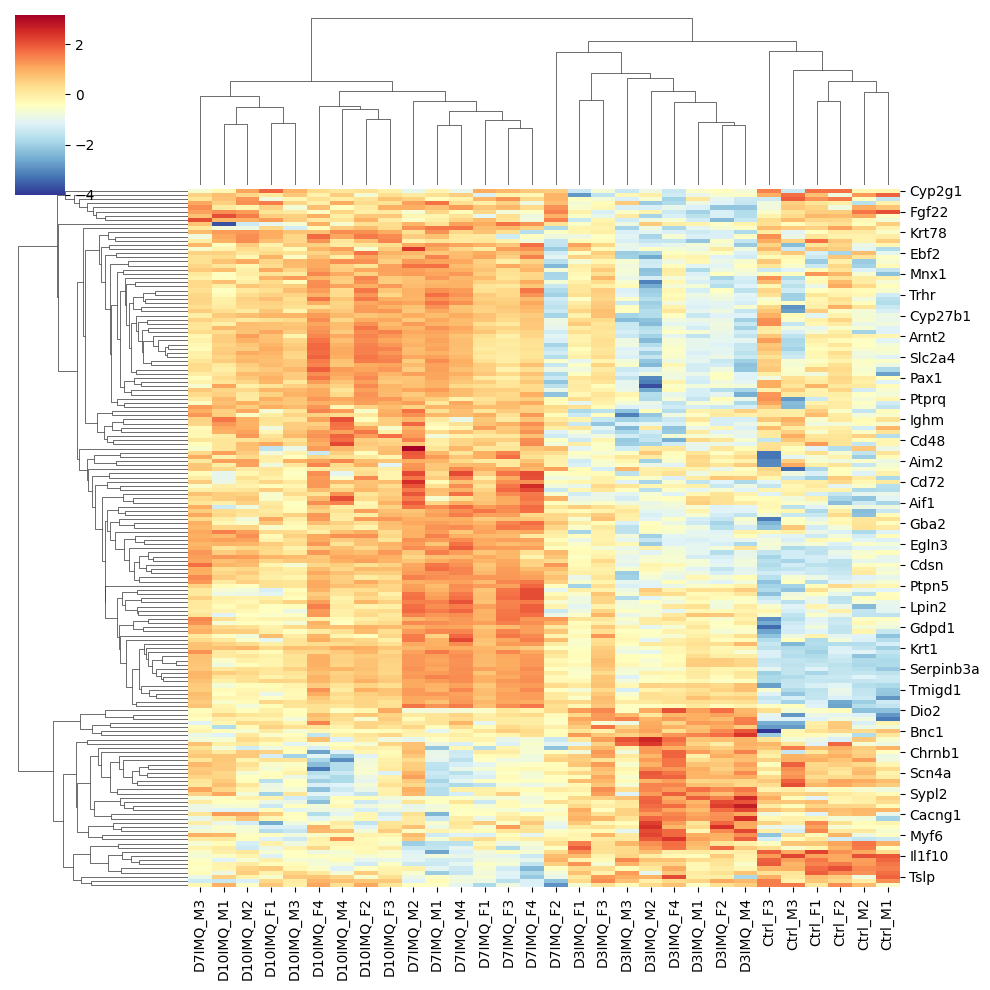

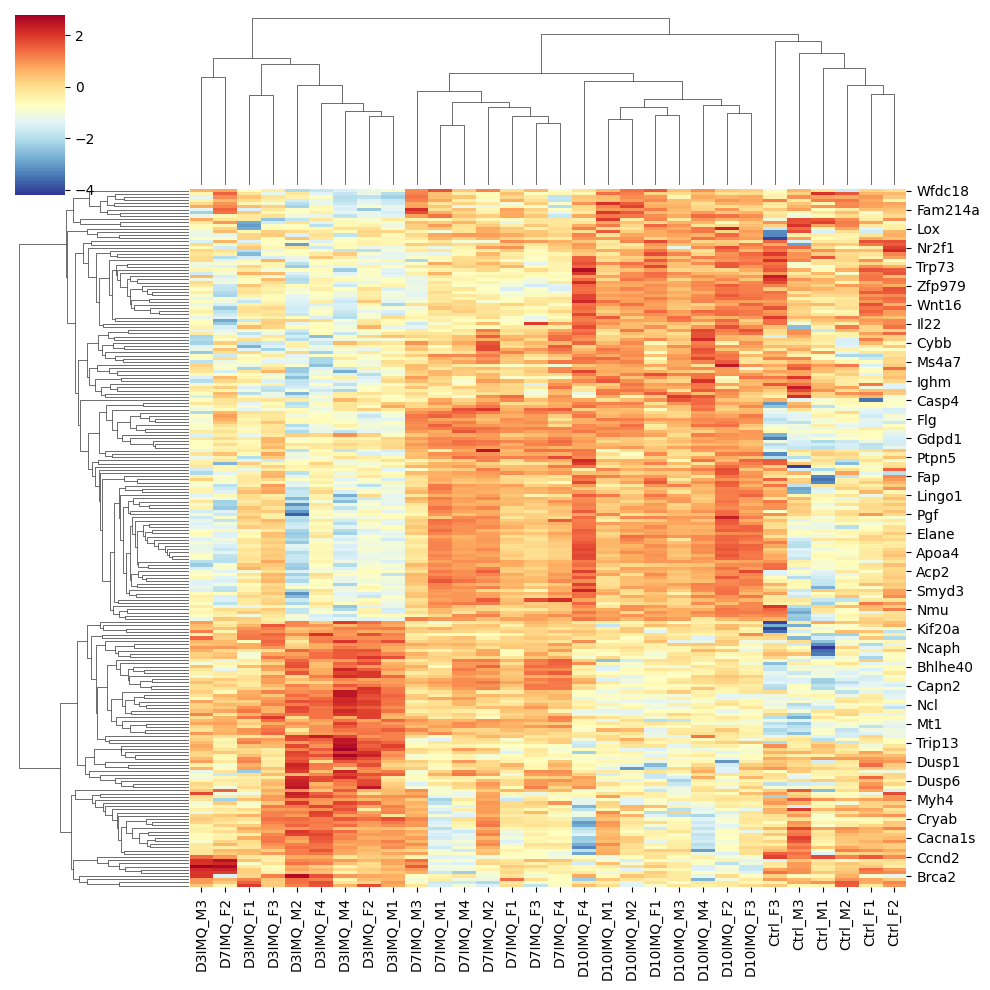

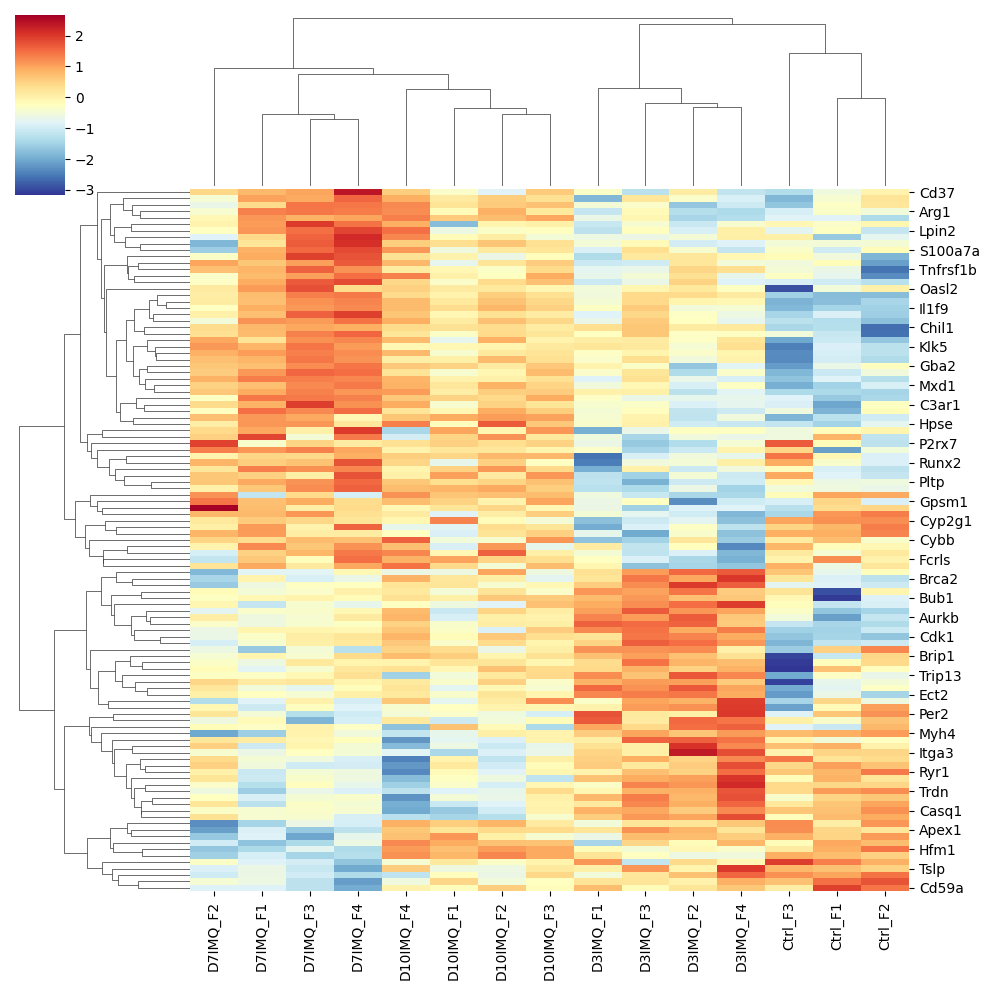

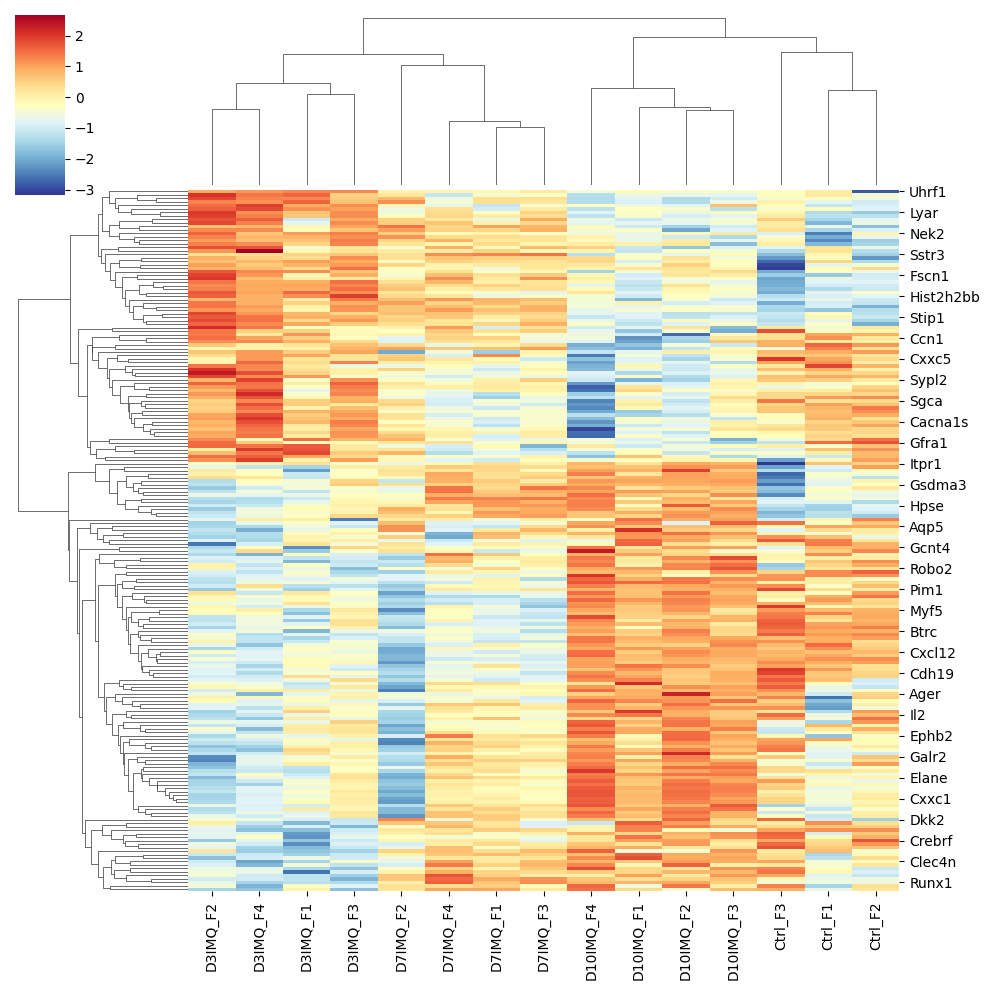

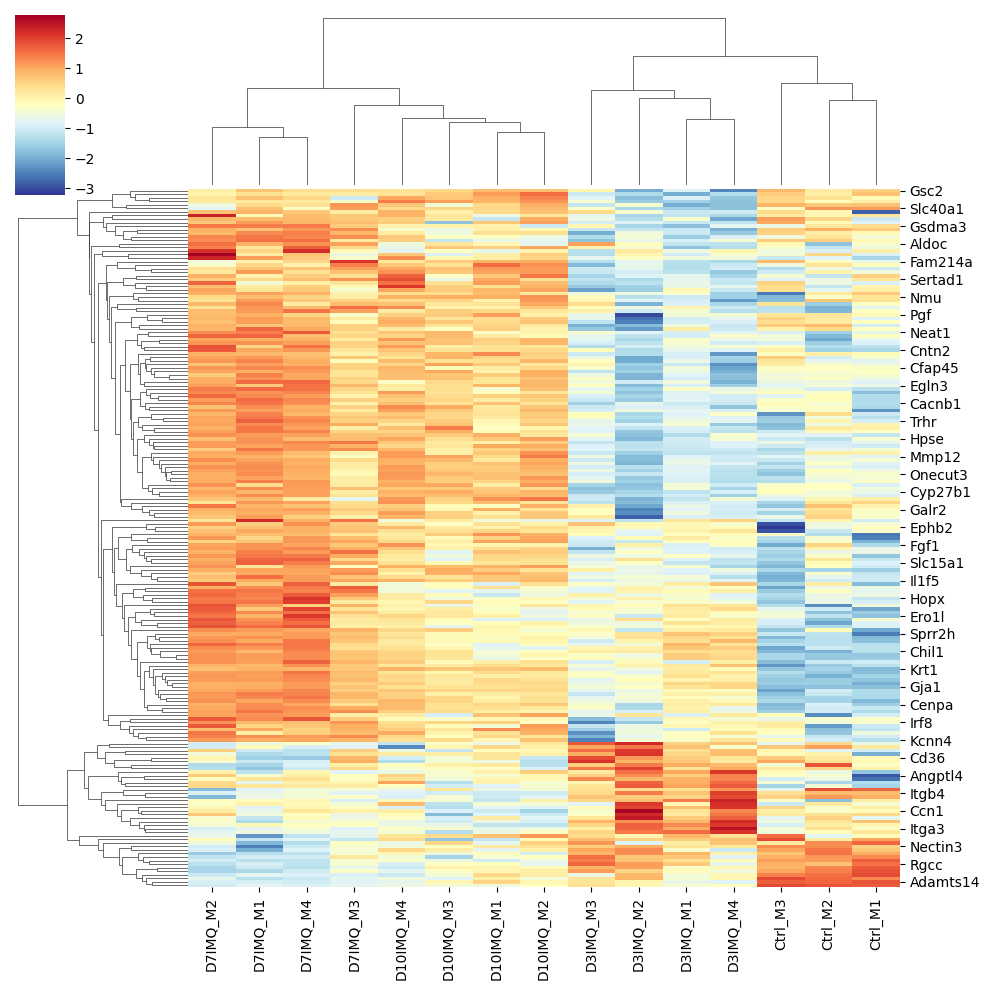

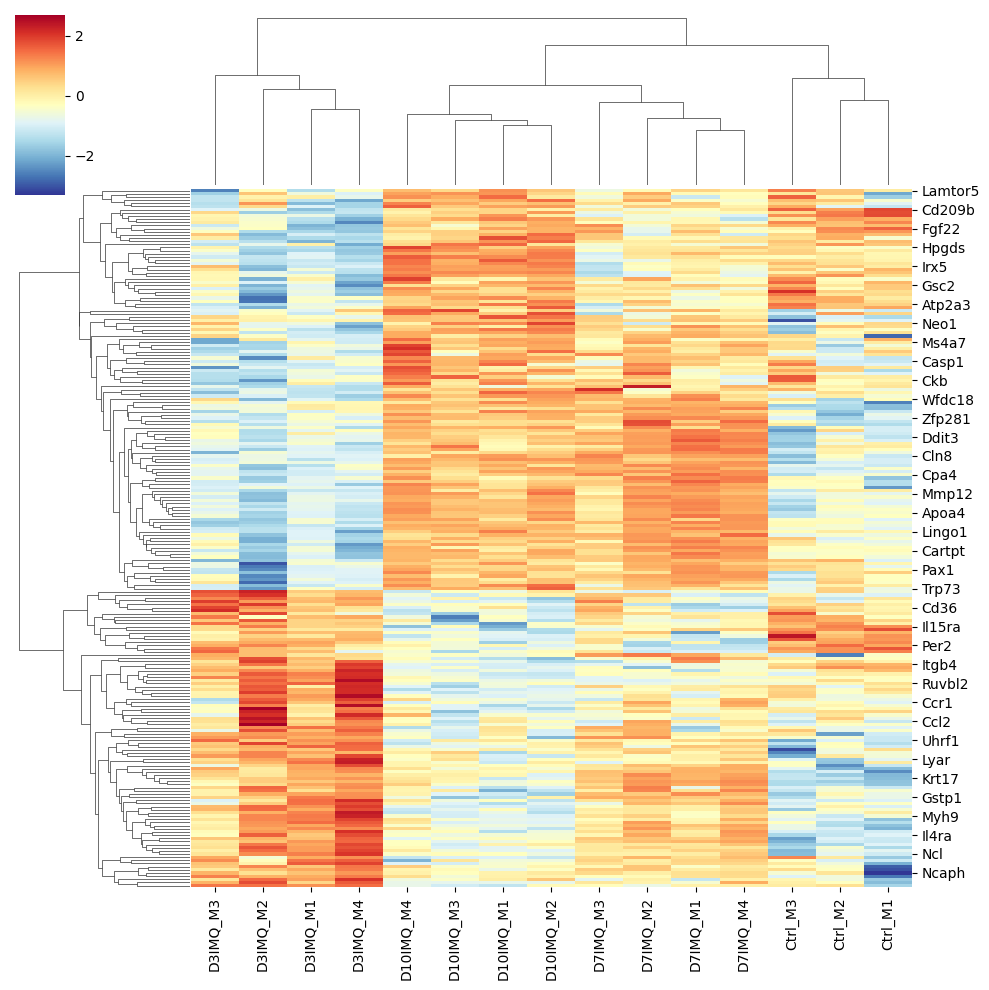

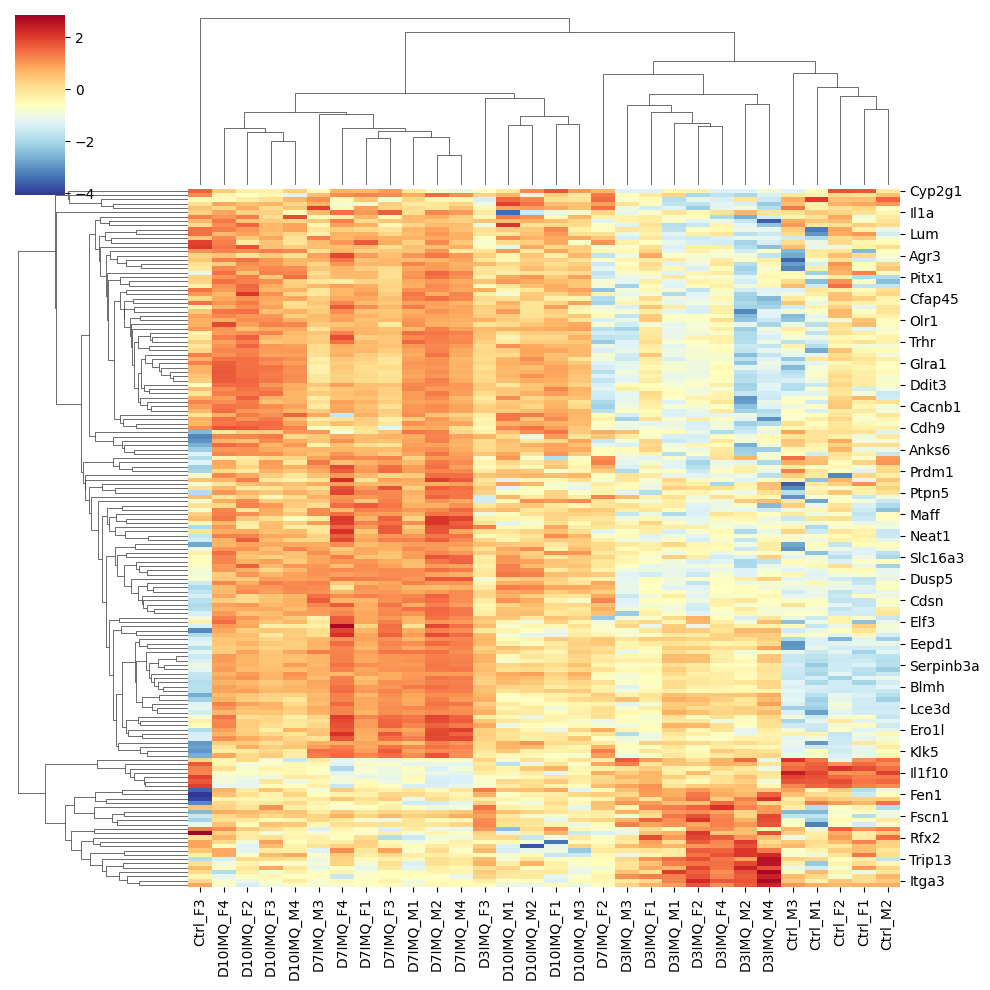

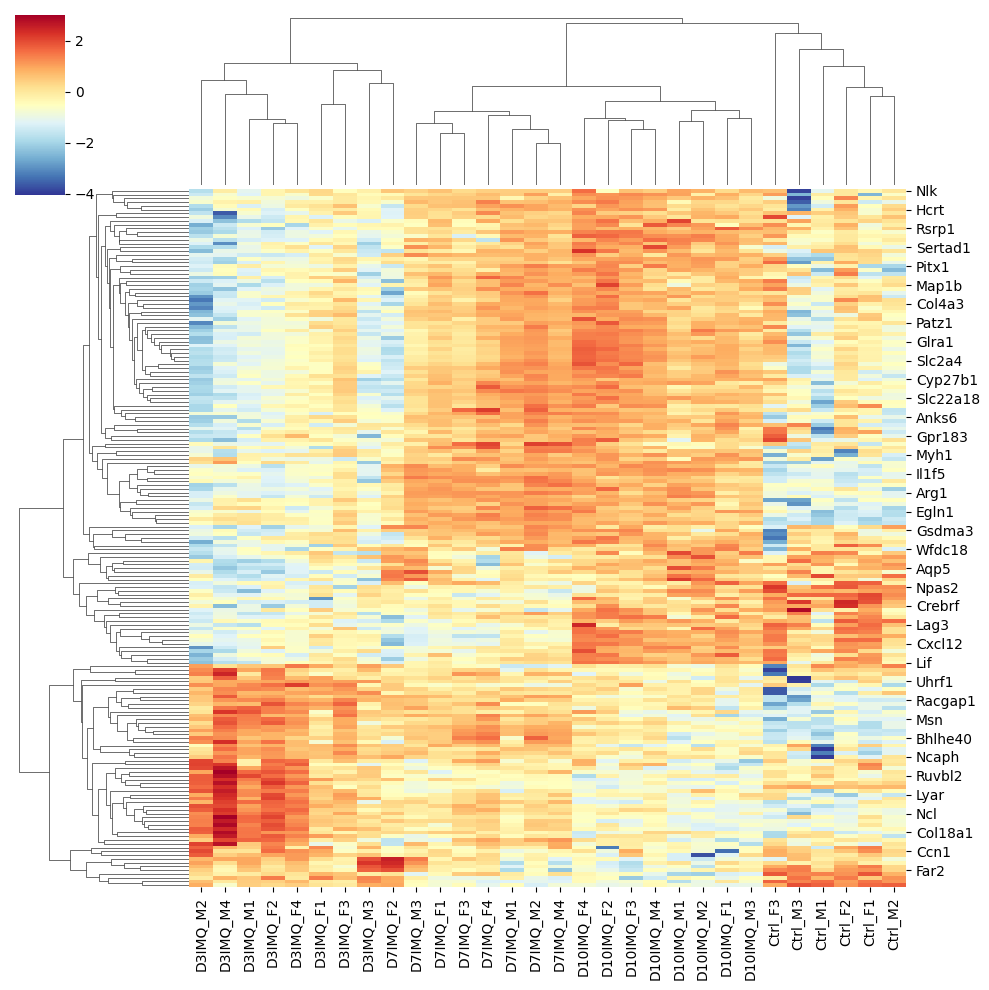

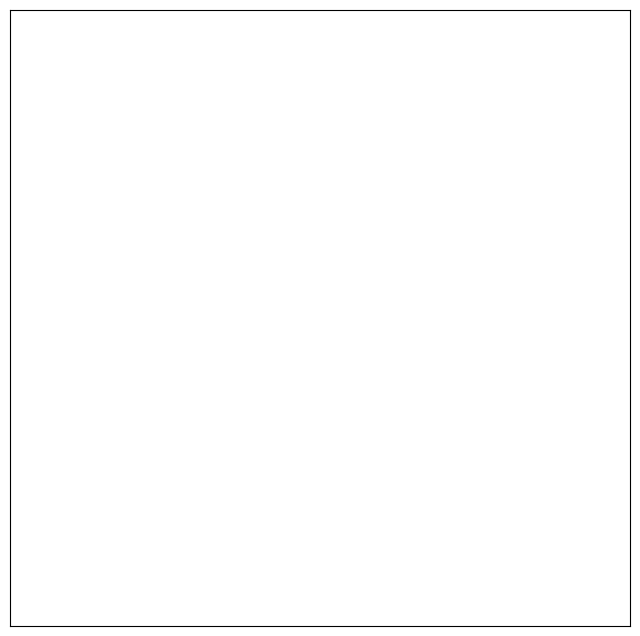

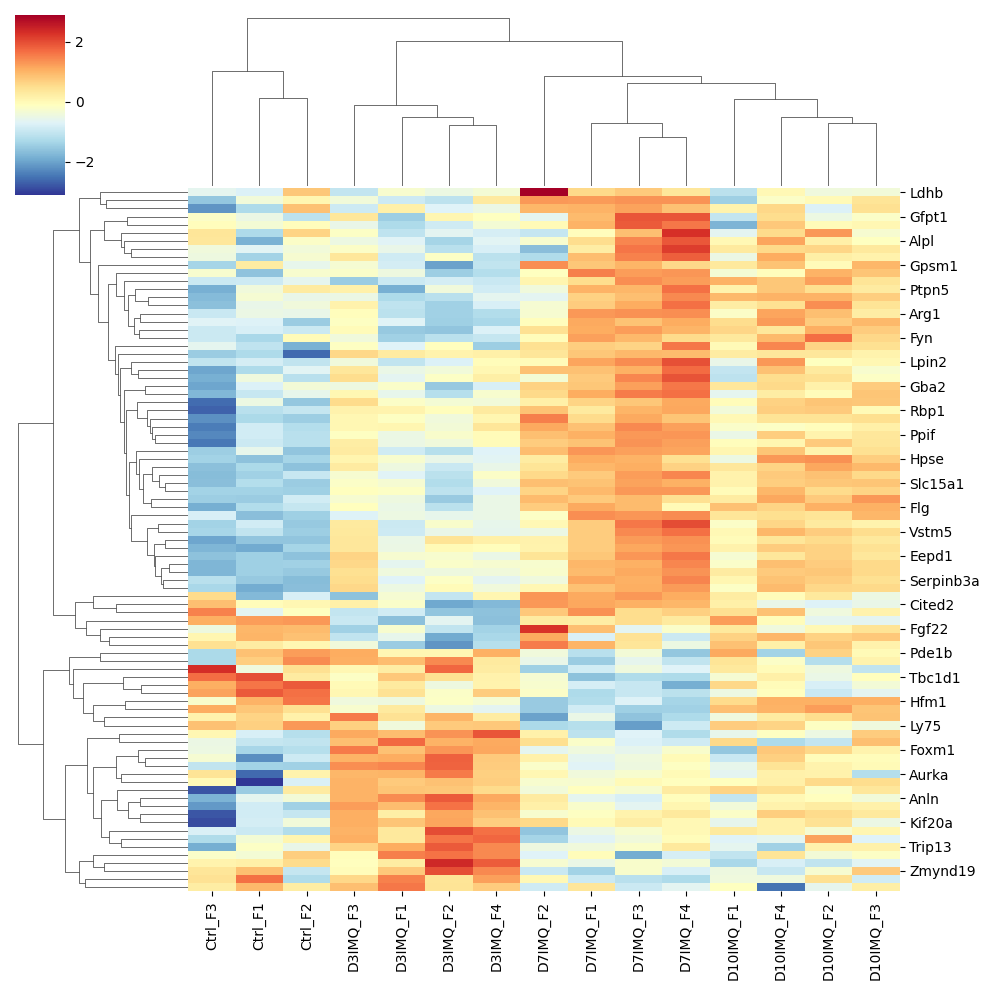

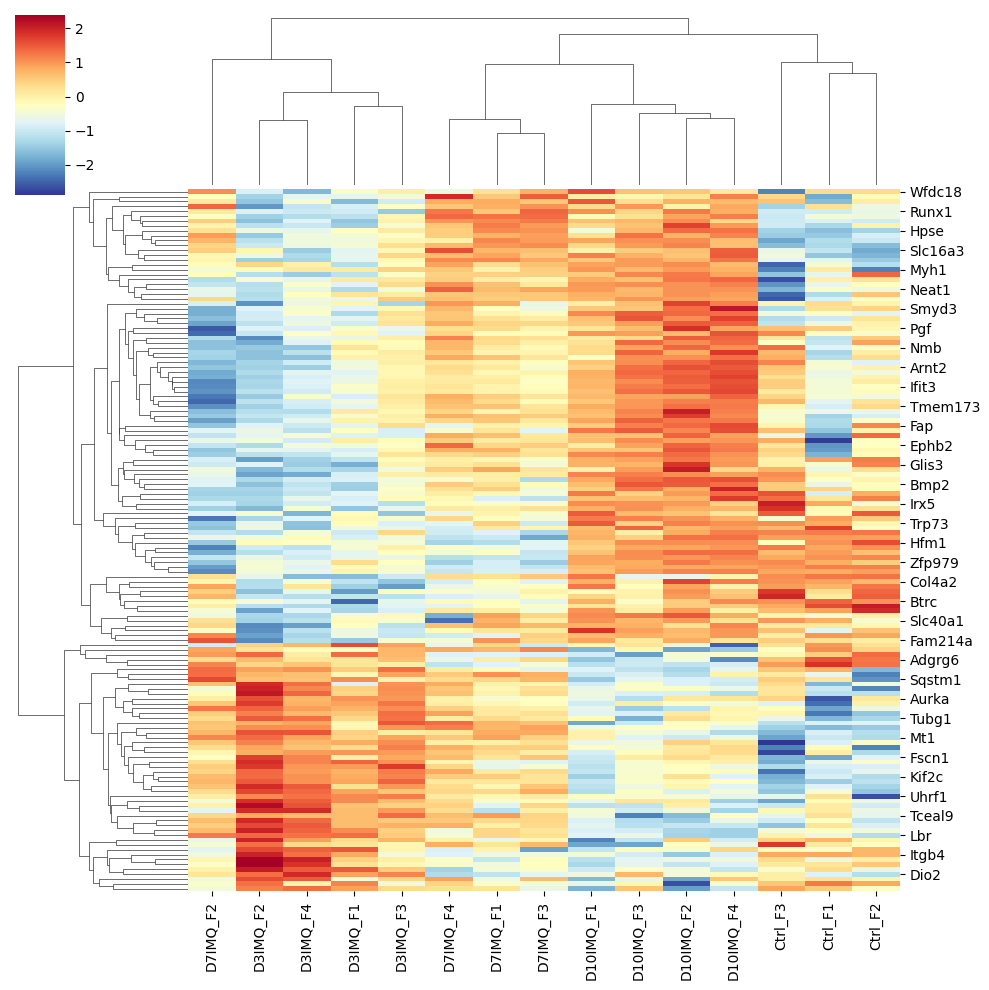

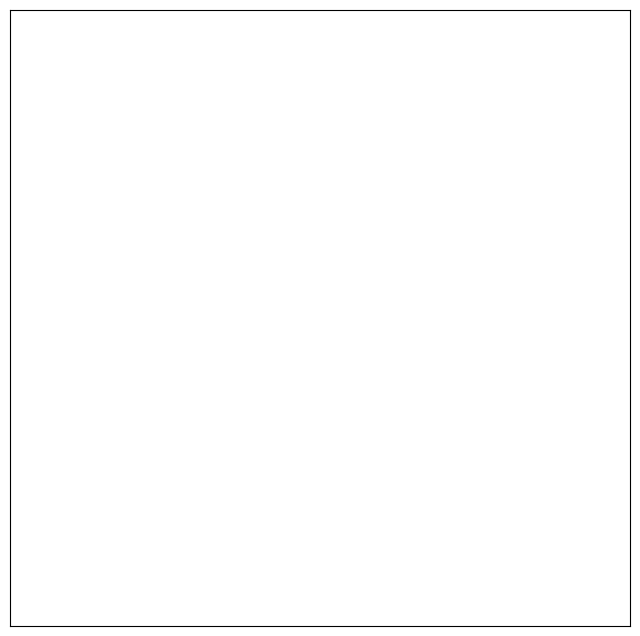

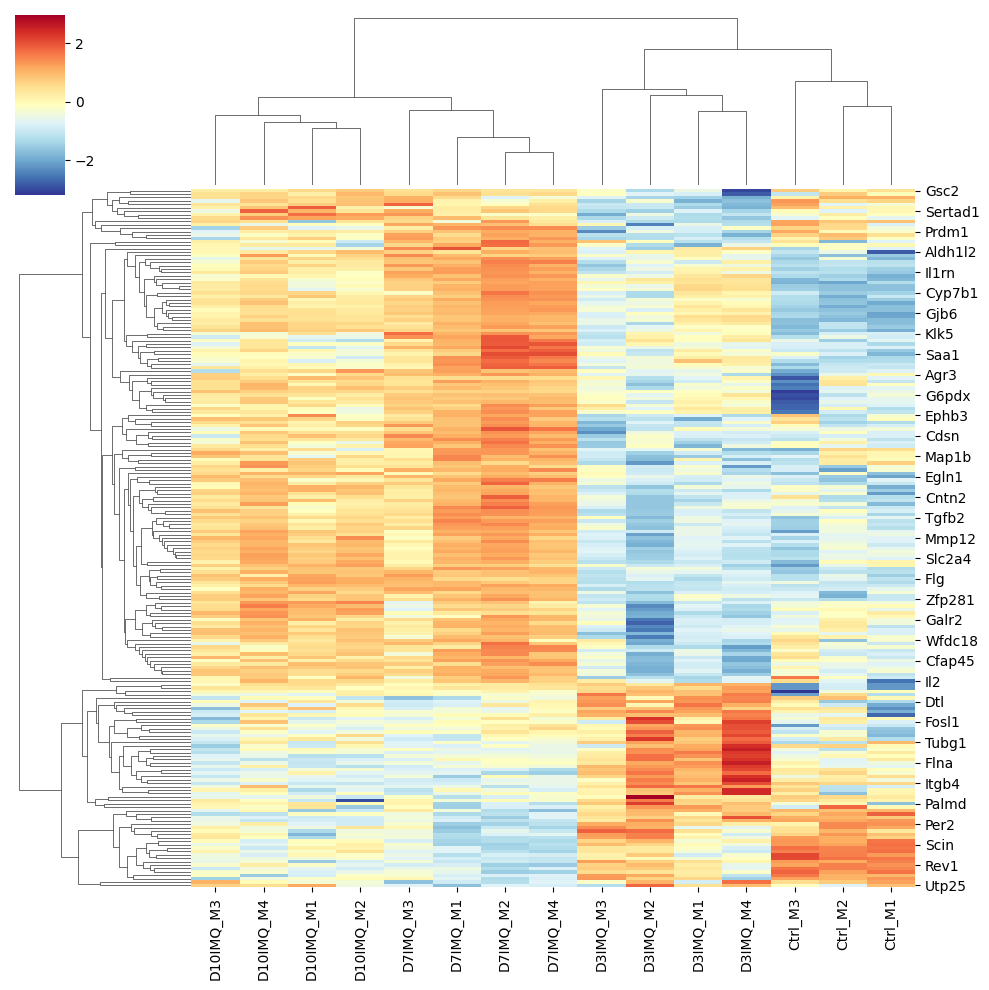

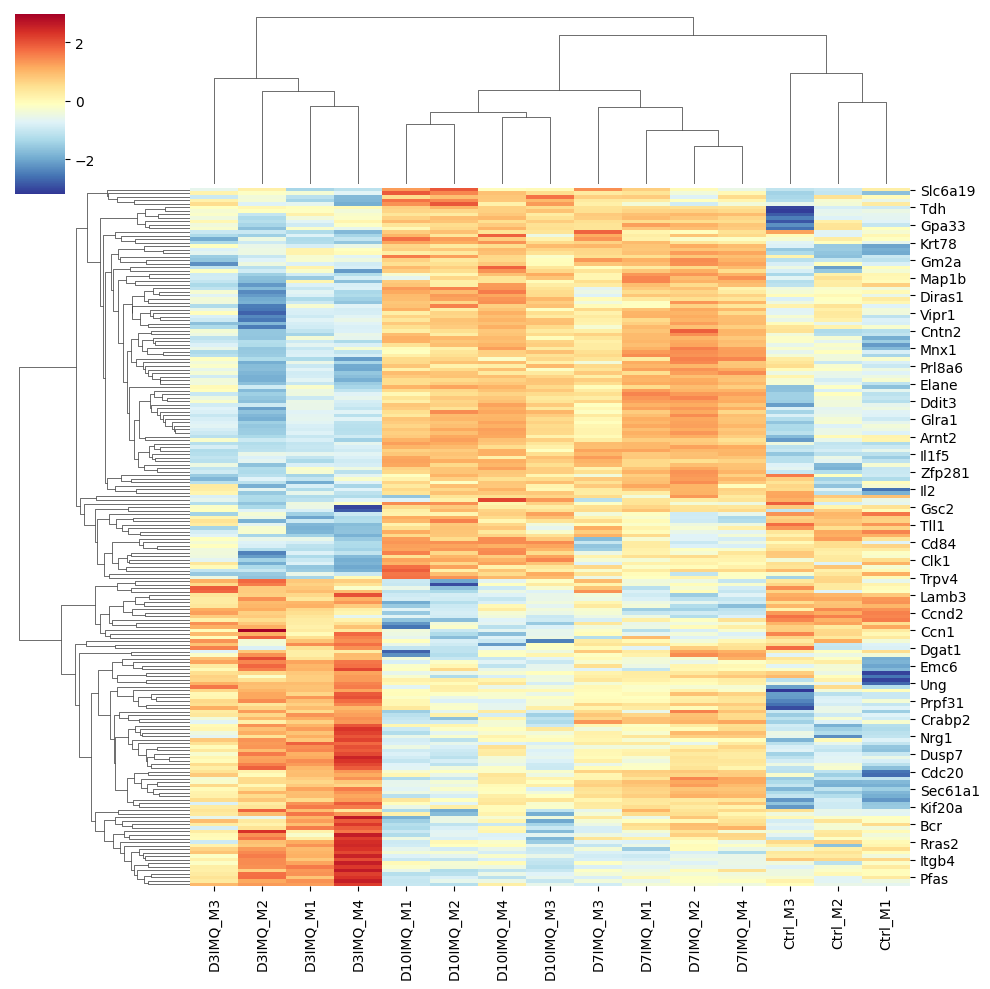

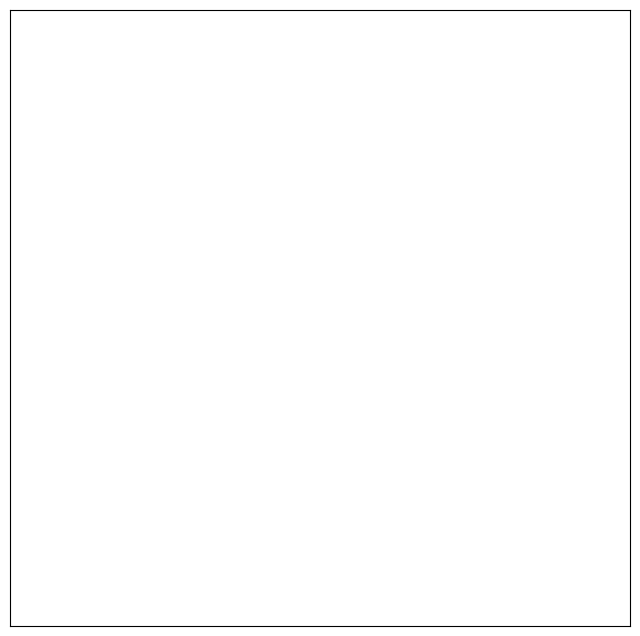

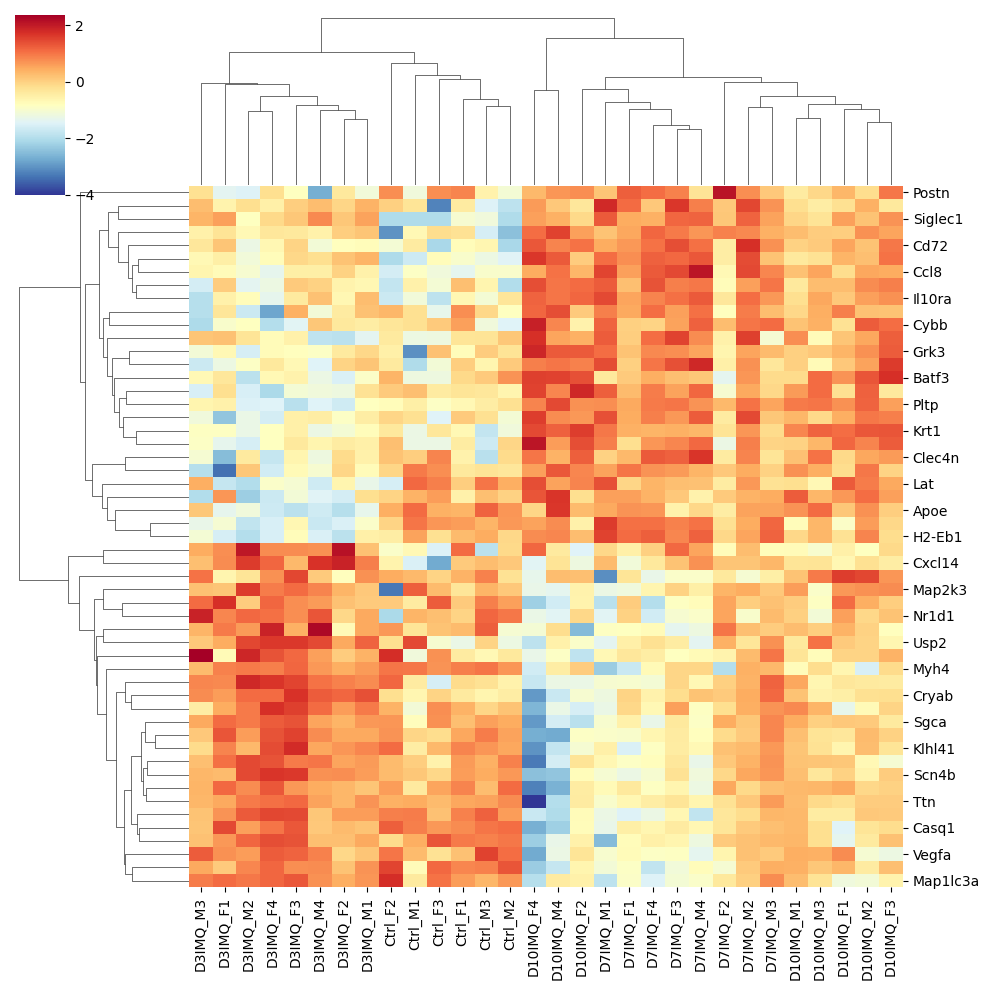

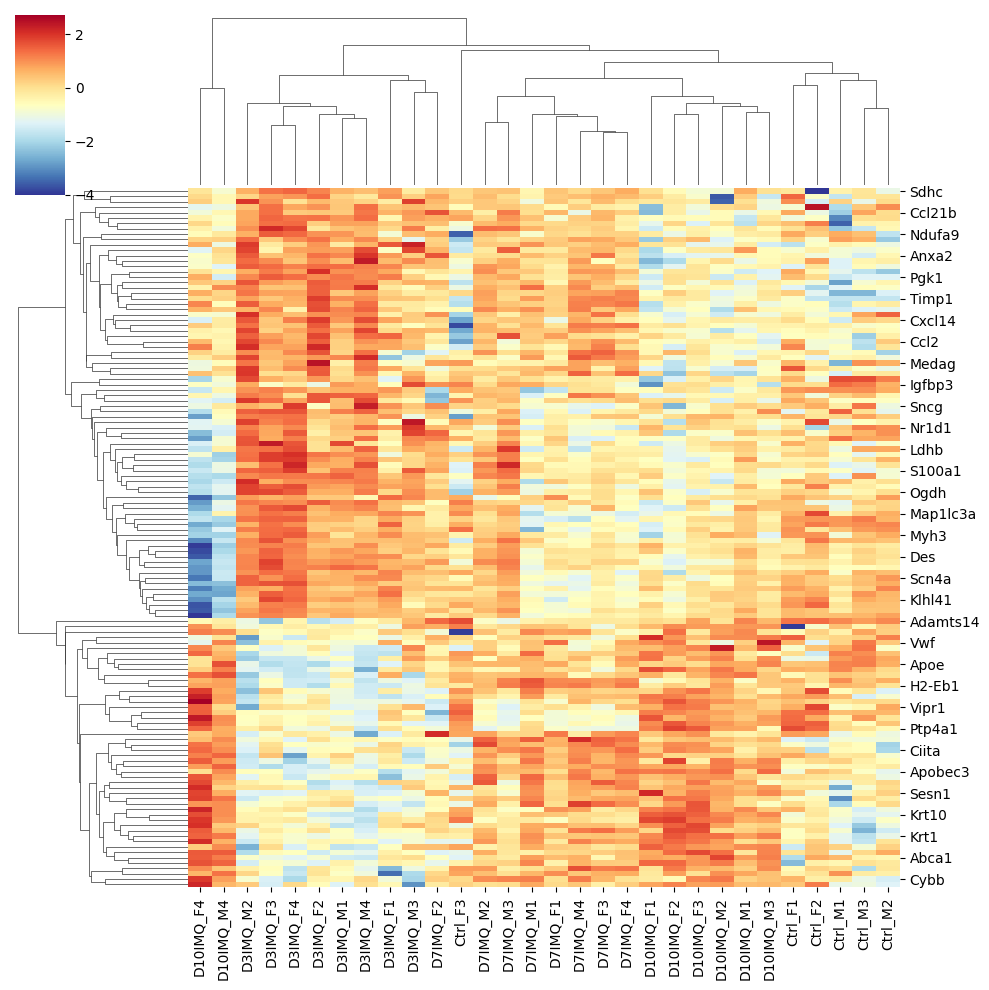

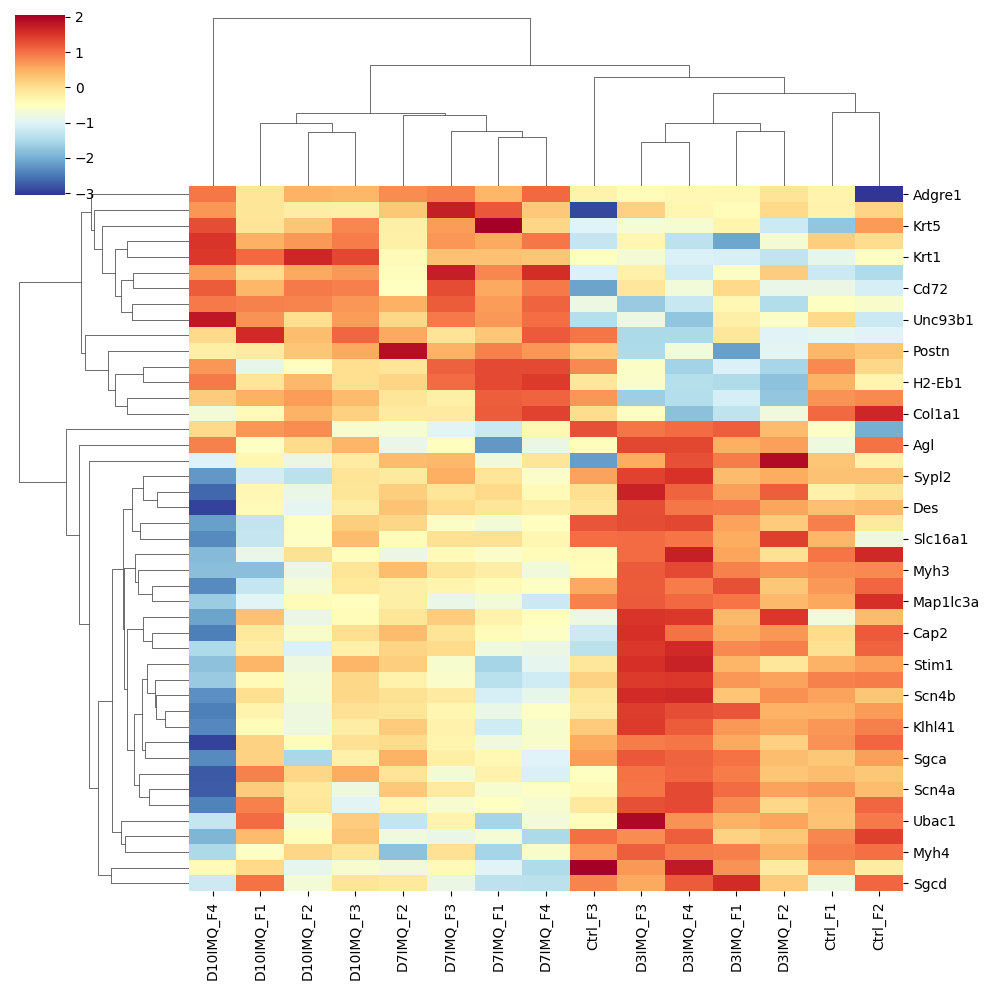

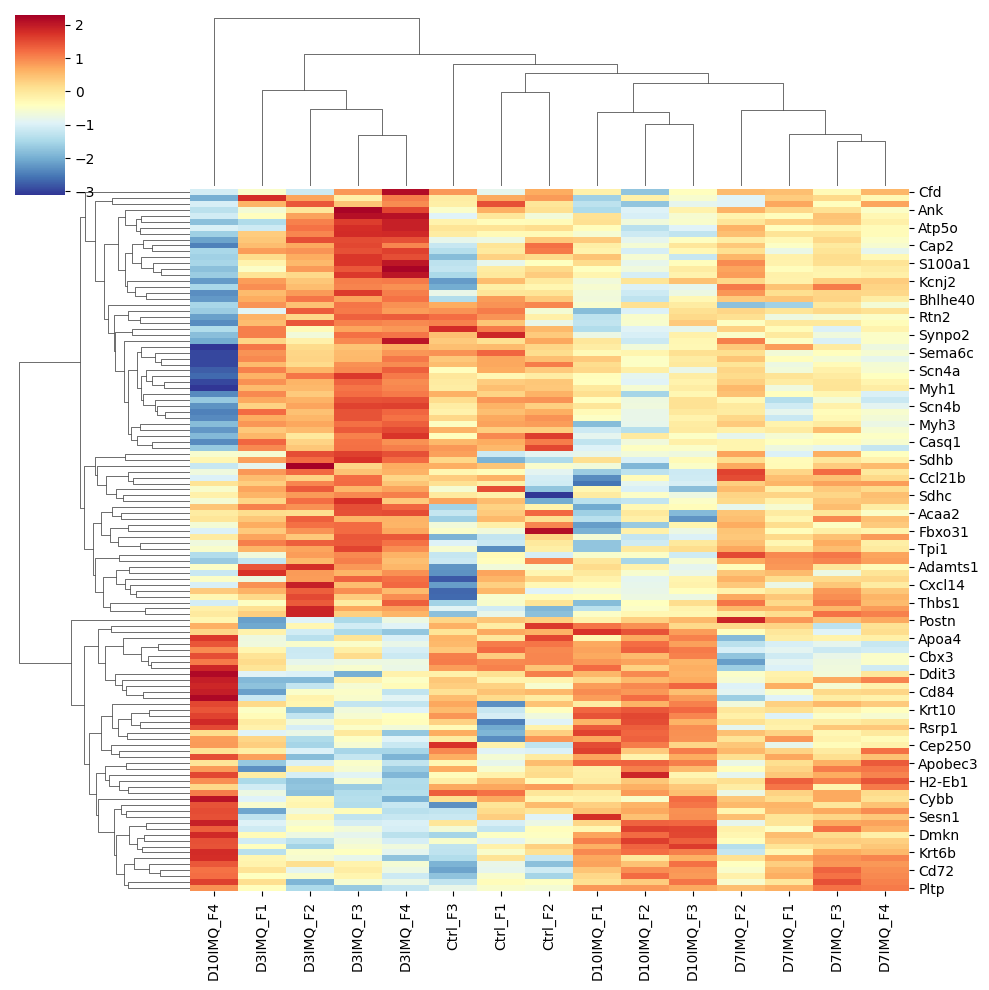

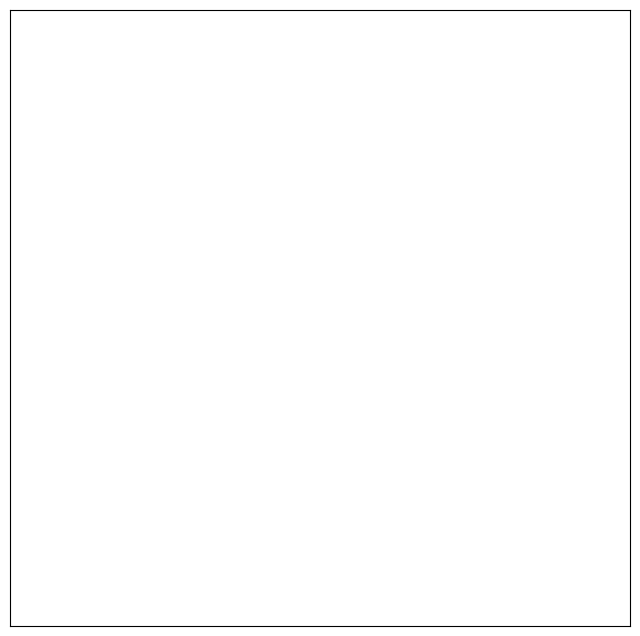

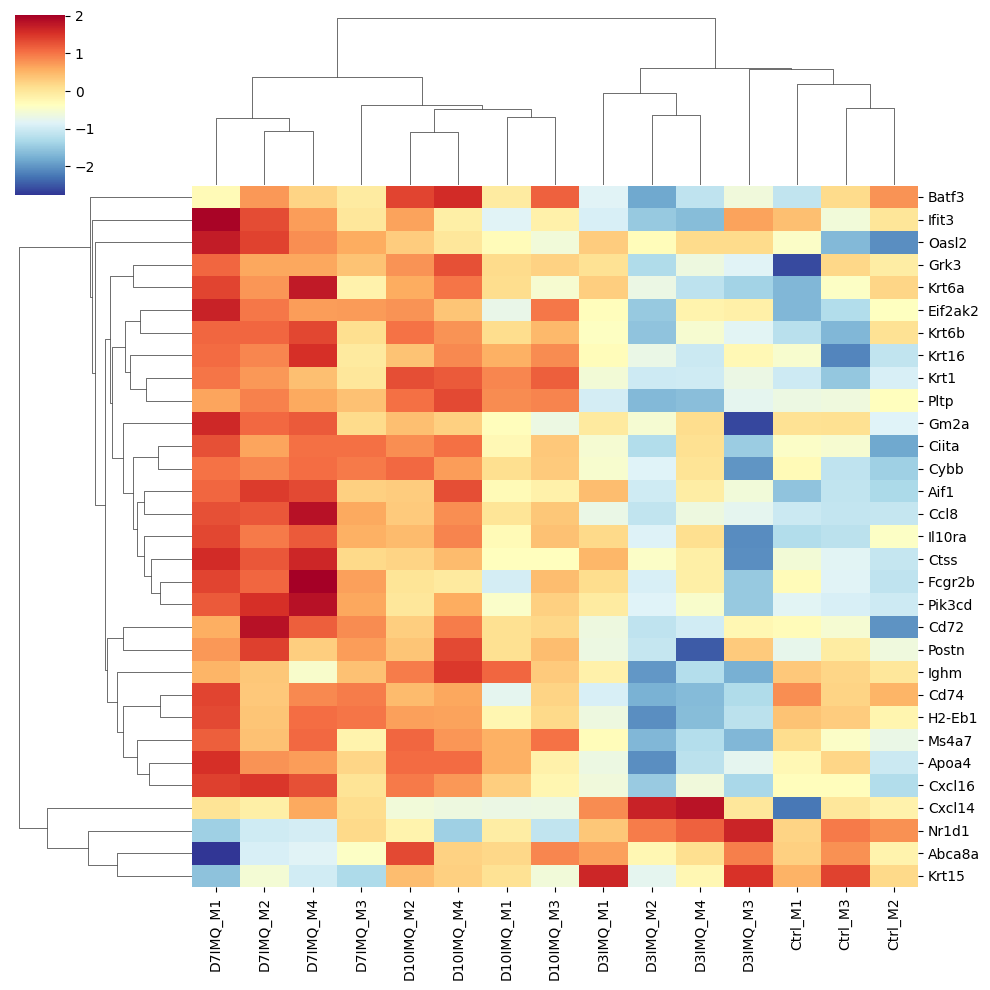

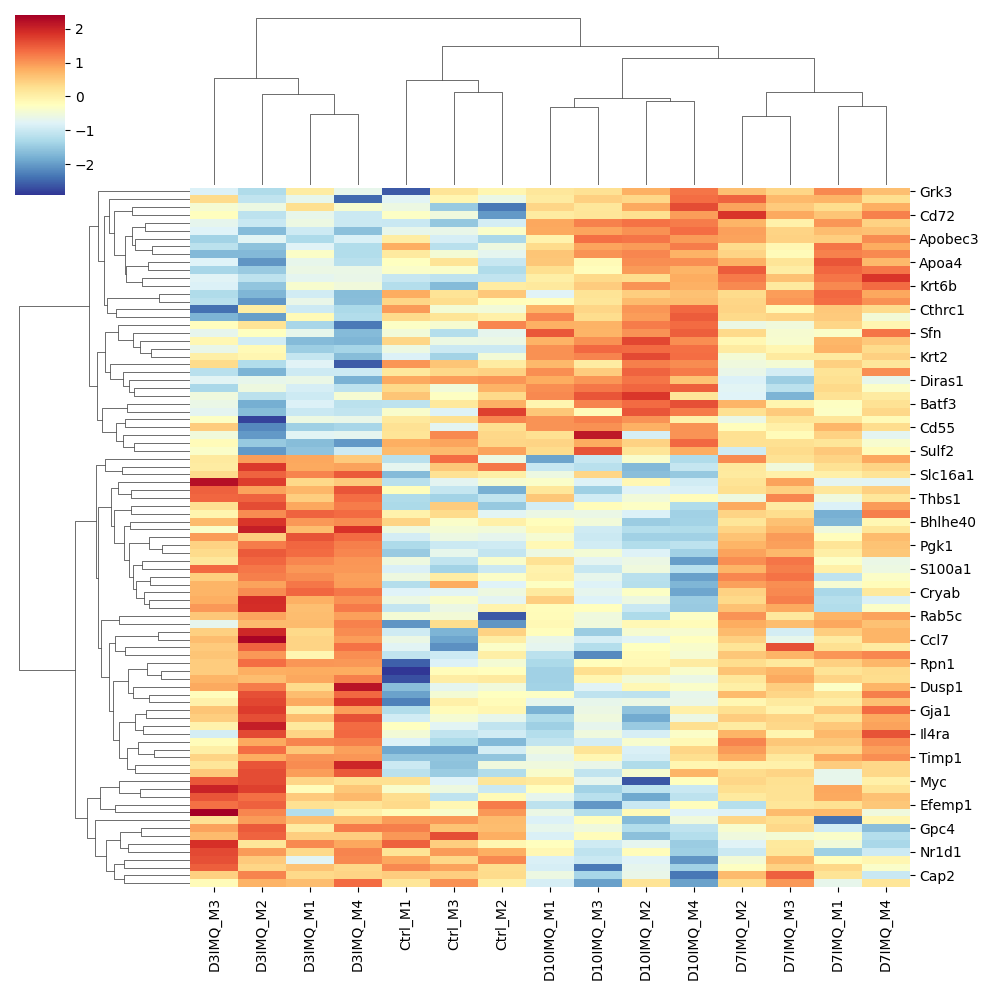

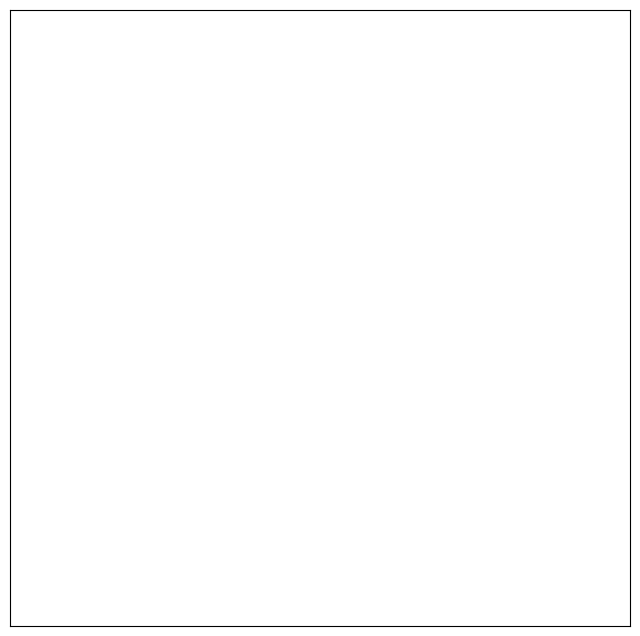

In [ ]:
#run on a whole dictionary - single object workflow in following cells
failed_deseq2 = []
low_DEs = []
small_GSEAs = []
failed_enrichments = []

for name, bulk in bulk_subtypes.items():
    if 'celltype' in name: #ignore celltype bulks
        continue
    #make a deseq data set from your anndata

    #avoid recalculating if already done
    if Path(results_path/ f'{name}_D3IMQ_D7IMQ_DEgenes.csv').exists(): #bit jammy, but if D3 is calced, then so are D7/D10
        continue

    dds = DeseqDataSet(counts = bulk.X,
                   metadata = bulk.obs,
                   design_factors = 'condition')
    dds.var = bulk.var


    #run deseq2 on it
    try:
        dds.deseq2()
    except:
        failed_deseq2.append(f'{name}')
        continue

    #get the stats
    for day in ['D7IMQ', 'D10IMQ']:
        stat_res = DeseqStats(dds, contrast = ['condition', day, 'D3IMQ']) #pairwise comparison of days with each condition
        stat_res.summary()
        #get diffexp dataframe
        res = stat_res.results_df
        res_file = f'{name}_D3IMQ_{day}_DEgenes.csv'
        res.to_csv(results_path / res_file) #save table with stats of DE genes
        
        #filtering any genes with baseMean <10, choice is somewhat arbitrary
        res = res[res.baseMean >10]
        #then filter all those that are not significant or large enough
        sigs = res[(abs(res.log2FoldChange) > 1)&(res.padj <0.05)] #again, log2fc threshold is bit arbitrary,being stringent so using 1.
        #check if yap1 is in the list of significantly expressed genes
        if 'Yap1' in sigs.index.to_list():
            print(f'{name}_D3IMQ_{day} has a significant change in YAP1')
        
        #plot VOLCANO PLOT and save
        volcano_plot_name = f'{name}_D3IMQ_{day}_volcano.png'

        save_dir = results_path / 'Volcano_plots'
        volcano_plot(res, volcano_plot_name, save_dir)
        
        #plot CLUSTERMAP for significant genes
        cluster_map_name = f'{name}_D3IMQ_{day}_cluster.png'
        cluster_map_path = results_path / 'clustermaps' / cluster_map_name
        if len(sigs) >2:
            dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])
            dds_sigs = dds[:, sigs.index].copy()

            grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                        index = dds_sigs.var_names, columns = dds_sigs.obs_names)
            
            clustermap = sns.clustermap(grapher, z_score = 0, cmap = 'RdYlBu_r')
            clustermap.savefig(cluster_map_path, bbox_inches = 'tight')
            plt.close
        else:
            low_DEs.append(f'{name}_D3IMQ_{day}')

        #do GSEA on your diffexped genes
        ranking = res['stat'].dropna().sort_values(ascending = False)

        for gene_set in ['GO_Biological_Process_2026', 'KEGG_2026']:
            if gene_set == 'GO_Biological_Process_2026':
                database = 'GO'
            else:
                database = 'KEGG' 
            
            try:
                pre_res = gp.prerank(rnk = ranking,
                        gene_sets = gene_set, #this can be a list, e.g. if you wanted to look at molecular function, or KEGG
                        organism = 'mouse',
                        seed = 6, permutation_num=100)
                print("succeeded 1")

                out = []
                for term in list(pre_res.results):
                    out.append([term,
                                pre_res.results[term]['fdr'],
                                pre_res.results[term]['es'],
                                pre_res.results[term]['nes']])
                print("succeeded 2")
                    
                out_df = pd.DataFrame(out, columns = ['Term', 'fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
                out_df.sort_values('nes', ascending = False)
                print("succeeded 3")



                out_df.to_csv(results_path / 'GSEA_csvs' / f'{name}_D3IMQ_{day}_{database}.csv')

                #plotting the ENRICHMENT MAP
                output_path = results_path / 'GSEA plots'/ f'{name}_D3IMQ_{day}_{database}.png'
                try:
                    enrichment_plot(pre_res, output_path)
                except:
                    print(f'no signficant {database} terms for {name}_D3IMQ{day}')
                    failed_enrichments.append(f'{name}_D3IMQ_{day}_{database}')
            except:
                small_GSEAs.append(f'{name}_D3IMQ_{day}_{database}')


print(failed_deseq2) 
print(low_DEs) 
print(small_GSEAs) 
print(failed_enrichments)

In [12]:
print(len(failed_deseq2)) 
print(len(low_DEs)) 
print(len(small_GSEAs)) 
print(len(failed_enrichments))

6
251
456
286


In [ ]:
# saving then reloading doesn't work --> will have to work out how to logic this into the loop
stat_res = DeseqStats(dds, contrast = ['condition', 'D3IMQ', 'Ctrl']) #note you will need to repeat this pairwise comparison for all 

AttributeError: 'AnnData' object has no attribute 'contrast'

In [76]:
stat_res

In [77]:
# summary statistics, must be run prior to stat_res.results_df
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition D3IMQ vs Ctrl
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1cf      3.224922       -1.439010  1.021326 -1.408963  0.158846  0.325711
A2m       6.196867       -0.583439  0.776584 -0.751289  0.452479  0.633777
Aanat     8.864367       -1.547721  0.568376 -2.723059  0.006468  0.035041
Aatf    188.950562        0.004707  0.151923  0.030983  0.975283  0.985773
Abca1   178.072072       -0.469179  0.181830 -2.580314  0.009871  0.047051
...            ...             ...       ...       ...       ...       ...
Zswim9    7.440184        0.478069  0.706172  0.676986  0.498415  0.673383
Zup1     19.374869       -0.420897  0.370645 -1.135579  0.256133  0.446745
Zyx      18.903959        0.757426  0.432946  1.749468  0.080210  0.202548
Zzef1   130.866450       -0.010049  0.163657 -0.061404  0.951038  0.972420
a         5.817857        1.281990  0.937843  1.366956  0.171639  0.344042

[5056 rows x 6 columns]


... done in 0.92 seconds.



In [78]:
res = stat_res.results_df
res # diffexp dataframe

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1cf,3.224922,-1.439010,1.021326,-1.408963,0.158846,0.325711
A2m,6.196867,-0.583439,0.776584,-0.751289,0.452479,0.633777
Aanat,8.864367,-1.547721,0.568376,-2.723059,0.006468,0.035041
Aatf,188.950562,0.004707,0.151923,0.030983,0.975283,0.985773
Abca1,178.072072,-0.469179,0.181830,-2.580314,0.009871,0.047051
...,...,...,...,...,...,...
Zswim9,7.440184,0.478069,0.706172,0.676986,0.498415,0.673383
Zup1,19.374869,-0.420897,0.370645,-1.135579,0.256133,0.446745
Zyx,18.903959,0.757426,0.432946,1.749468,0.080210,0.202548
Zzef1,130.866450,-0.010049,0.163657,-0.061404,0.951038,0.972420


In [79]:
#filtering any genes with baseMean <10, choice is somewhat arbitrary
res = res[res.baseMean >10]

#then filter all those that are not significant or large enough
sigs = res[(abs(res.log2FoldChange) > 1)&(res.padj <0.05)] #again, log2fc threshold is bit arbitrary,being stringent so using 1.

#check if yap1 is in the list of significantly expressed genes
'Yap1' in sigs.index.to_list()

False

As we can see, Yap1 is not differentially expressed at the bulk level between Ctrl and any other condition. 

## Looking at DE results

In [32]:
yap1_target_geneset = ['Yap1', 'Ccn1', 'Ccn2', 'Birc5', 'Birc2', 'Ccnd1', 'Axl', 'Plau','Aurkb', 'Tgfbr3', 'Dkk1',
                       'Itgb2', 'Hoxa1', 'Hoxc13']

In [33]:
from pathlib import Path
import pandas as pd
import numpy as np

base_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs")
#path_with_DEs = Path(base_path /"DESEQ_bulk_D3_D7_results")
de_nums = {}
yap_de = {}

for folder in base_path.glob("DESEQ*"):
    path_with_DEs = Path(base_path/folder)


    for csv in path_with_DEs.glob("*.csv"):
        df = pd.read_csv(path_with_DEs / csv, index_col = 0)
        filtered = df[df.baseMean >10]

        #then filter all those that are not significant or large enough
        filtered = filtered[(abs(filtered.log2FoldChange) > 1)&(filtered.padj <0.05)] 

        #check for Yap1 targets
        hits = [gene for gene in yap1_target_geneset if gene in filtered.index]
        if hits:
            yap_de[csv.stem] = hits
        if len(filtered) > 99:
            de_nums[csv.stem] = len(filtered)

    print(len(yap_de))

19
51
67
82


In [35]:
yap_de

{'big_bulk_Ctrl_D3IMQ_DEgenes': ['Birc5', 'Aurkb'],
 'big_bulk_Ctrl_D7IMQ_DEgenes': ['Tgfbr3'],
 'big_bulk_Ctrl_D10IMQ_DEgenes': ['Ccn1', 'Aurkb', 'Tgfbr3'],
 'big_bulk_F_Ctrl_D3IMQ_DEgenes': ['Aurkb'],
 'big_bulk_F_Ctrl_D10IMQ_DEgenes': ['Tgfbr3'],
 'big_bulk_M_Ctrl_D3IMQ_DEgenes': ['Ccn2', 'Birc5', 'Aurkb'],
 'big_bulk_M_Ctrl_D7IMQ_DEgenes': ['Ccn2', 'Birc5', 'Tgfbr3'],
 'big_bulk_epidermis_Ctrl_D3IMQ_DEgenes': ['Birc5', 'Aurkb', 'Tgfbr3'],
 'big_bulk_epidermis_Ctrl_D7IMQ_DEgenes': ['Ccn1', 'Tgfbr3'],
 'big_bulk_epidermis_Ctrl_D10IMQ_DEgenes': ['Tgfbr3'],
 'big_bulk_epidermis_F_Ctrl_D3IMQ_DEgenes': ['Aurkb'],
 'big_bulk_epidermis_F_Ctrl_D7IMQ_DEgenes': ['Tgfbr3'],
 'big_bulk_epidermis_F_Ctrl_D10IMQ_DEgenes': ['Tgfbr3'],
 'big_bulk_epidermis_M_Ctrl_D3IMQ_DEgenes': ['Birc5', 'Ccnd1', 'Aurkb'],
 'big_bulk_epidermis_M_Ctrl_D7IMQ_DEgenes': ['Birc5', 'Tgfbr3'],
 'big_bulk_epidermis_M_Ctrl_D10IMQ_DEgenes': ['Tgfbr3'],
 'big_bulk_dermis_Ctrl_D7IMQ_DEgenes': ['Itgb2'],
 'big_bulk_dermis_M_Ctr

In [39]:
for name, list in yap_de.items():
    if ('Tgfbr3' in list) & (len(list) >1):
        print(name, list)

big_bulk_Ctrl_D10IMQ_DEgenes ['Ccn1', 'Aurkb', 'Tgfbr3']
big_bulk_M_Ctrl_D7IMQ_DEgenes ['Ccn2', 'Birc5', 'Tgfbr3']
big_bulk_epidermis_Ctrl_D3IMQ_DEgenes ['Birc5', 'Aurkb', 'Tgfbr3']
big_bulk_epidermis_Ctrl_D7IMQ_DEgenes ['Ccn1', 'Tgfbr3']
big_bulk_epidermis_M_Ctrl_D7IMQ_DEgenes ['Birc5', 'Tgfbr3']
corneocyte_celltype_bulk_M_Ctrl_D7IMQ_DEgenes ['Birc2', 'Tgfbr3']
corneocyte_celltype_bulk_M_Ctrl_D10IMQ_DEgenes ['Birc2', 'Tgfbr3']
corneocyte_celltype_bulk_epidermis_M_Ctrl_D7IMQ_DEgenes ['Birc2', 'Tgfbr3']
corneocyte_celltype_bulk_epidermis_M_Ctrl_D10IMQ_DEgenes ['Birc2', 'Tgfbr3']
follicle_cell_celltype_bulk_dermis_Ctrl_D10IMQ_DEgenes ['Ccnd1', 'Tgfbr3']
follicle_cell_celltype_bulk_dermis_F_Ctrl_D7IMQ_DEgenes ['Ccnd1', 'Tgfbr3']
follicle_cell_celltype_bulk_dermis_F_Ctrl_D10IMQ_DEgenes ['Ccnd1', 'Tgfbr3']
corneocyte_celltype_bulk_M_D3IMQ_D7IMQ_DEgenes ['Birc2', 'Tgfbr3']
corneocyte_celltype_bulk_M_D3IMQ_D10IMQ_DEgenes ['Birc2', 'Tgfbr3']
corneocyte_celltype_bulk_epidermis_M_D3IMQ_D7IMQ_DEg

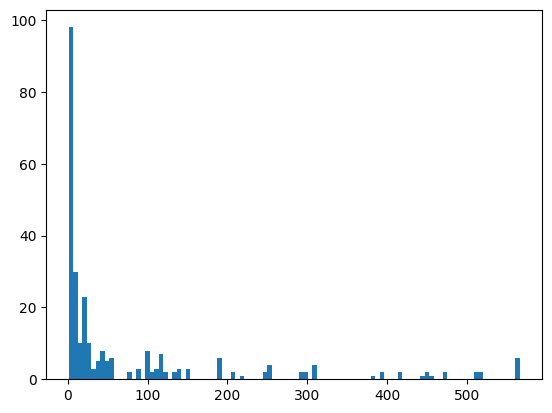

18.0
81.03971119133574
566


In [100]:
#visualising the distribution of no. DExp genes
import matplotlib.pyplot as plt
plt.hist(de_nums, bins = 100)
plt.show()

print(np.median(de_nums))
print(np.mean(de_nums))
print(np.max(de_nums))



In [ ]:
len
len([x for x in de_nums if x > 99]) #how many conditions are there where there are more than 100 differentially expressed genes?

67

### Volcano plot of DExped genes

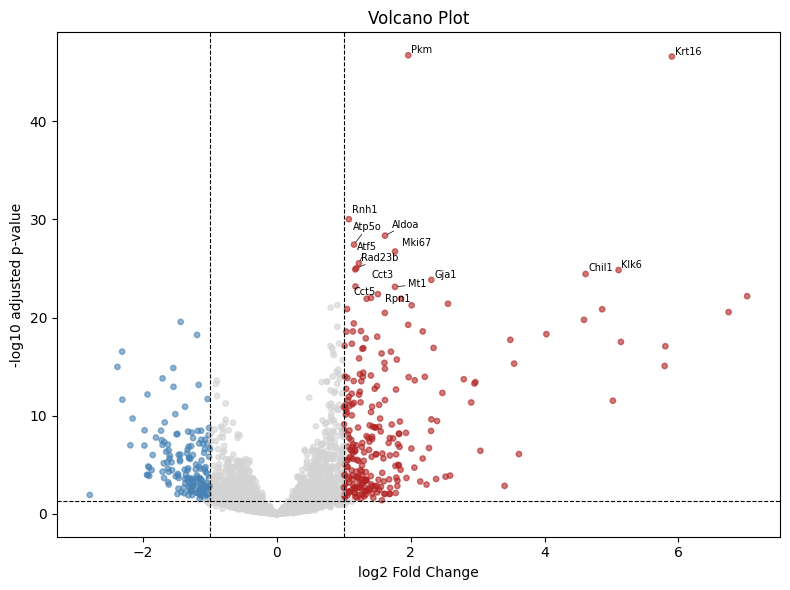

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text   # pip install adjustText

def volcano_plot(df, title, save_dir):
    df = df.dropna(subset=['log2FoldChange', 'padj'])
    df['-log10padj'] = -np.log10(df['padj'])

    fc_thresh = 1.0
    padj_thresh = 0.05
    n_labels = 20  # number of top genes to label

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot all points
    colours = np.where(
        (df['padj'] < padj_thresh) & (df['log2FoldChange'] > fc_thresh), 'firebrick',
        np.where(
            (df['padj'] < padj_thresh) & (df['log2FoldChange'] < -fc_thresh), 'steelblue', 'lightgrey'
        )
    )
    ax.scatter(df['log2FoldChange'], df['-log10padj'], c=colours, alpha=0.6, s=15)

    # Label top genes by significance
    top_genes = df.nsmallest(n_labels, 'padj')
    texts = [
        ax.text(row['log2FoldChange'], row['-log10padj'], gene, fontsize=7)
        for gene, row in top_genes.iterrows()
    ]
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    ax.axhline(-np.log10(padj_thresh), color='black', linestyle='--', linewidth=0.8)
    ax.axvline(fc_thresh, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(-fc_thresh, color='black', linestyle='--', linewidth=0.8)

    ax.set_xlabel('log2 Fold Change')
    ax.set_ylabel('-log10 adjusted p-value')
    ax.set_title(title)
    
    save_path = save_dir / (title)
    plt.save_fig(save_path)

# Looking at GSEA results

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

base_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs")
#path_with_DEs = Path(base_path /"DESEQ_bulk_D3_D7_results")
sig_GSEA_dfs = {} #dictionary of comparison conditions and gsea terms

for folder in base_path.glob("DESEQ*"):
    path_with_GSEAs = Path(base_path/folder/'GSEA_csvs')
    for csv in path_with_GSEAs.glob("*.csv"):
        df = pd.read_csv(path_with_GSEAs / csv)

        filtered = df[df['fdr'] <0.1]
        if len(filtered)>0:
            sig_GSEA_dfs[csv.stem] = filtered['Term']

In [13]:
for name, i in sig_GSEA_dfs.items():
    if (len(i) < 2) & (len(i) >0):
        print(name, i)

big_bulk_epidermis_ctrl_D3IMQ_KEGG 0    CORNIFIED ENVELOPE FORMATION
Name: Term, dtype: object
big_bulk_epidermis_ctrl_D10IMQ_KEGG 0    CORNIFIED ENVELOPE FORMATION
Name: Term, dtype: object
big_bulk_dermis_M_ctrl_D10IMQ_GO 0    Heart Development (GO:0007507)
Name: Term, dtype: object
activated_intermediate_basal_suprabasal_KC_celltype_bulk_ctrl_D3IMQ_KEGG 0    CORNIFIED ENVELOPE FORMATION
Name: Term, dtype: object
activated_intermediate_basal_suprabasal_KC_celltype_bulk_ctrl_D7IMQ_KEGG 0    CORNIFIED ENVELOPE FORMATION
Name: Term, dtype: object
activated_intermediate_basal_suprabasal_KC_celltype_bulk_ctrl_D10IMQ_GO 0    Supramolecular Fiber Organization (GO:0097435)
Name: Term, dtype: object
activated_intermediate_basal_suprabasal_KC_celltype_bulk_ctrl_D10IMQ_KEGG 0    CORNIFIED ENVELOPE FORMATION
Name: Term, dtype: object
activated_spinous_celltype_bulk_ctrl_D3IMQ_KEGG 0    CORNIFIED ENVELOPE FORMATION
Name: Term, dtype: object
activated_spinous_celltype_bulk_ctrl_D10IMQ_KEGG 0    CO

## GSEA analysis --> not strictly part of analysis but good to have

In [17]:
import gseapy as gp
from gseapy import gseaplot

In [97]:
ranking = res['stat'].dropna().sort_values(ascending = False) #generate dataframe of DExped genes, sorted from most downregged to most upregged
ranking

Pkm        15.044512
Krt16      14.978822
Rnh1       12.150447
Aldoa      11.807532
Atp5o      11.609670
             ...    
Col7a1     -8.509131
Krt15      -8.540492
Nkd2       -8.966274
Plekha5    -9.420892
Gabbr1     -9.764410
Name: stat, Length: 3418, dtype: float64

In [22]:
#look at available gene ontology libraries
library_list = gp.get_library_name()
for i in library_list:
    if 'KEGG' in i:
        print(i)

KEGG_2013
KEGG_2015
KEGG_2016
KEGG_2019_Human
KEGG_2019_Mouse
KEGG_2021_Human
KEGG_2026


In [ ]:
pre_res = gp.prerank(rnk = ranking,
                     gene_sets = 'GO_Biological_Process_2026', #this can be a list, e.g. if you wanted to look at molecular function, or KEGG
                     organism = 'mouse',
                     seed = 6, permutation_num=100)

In [108]:
#get the dataframe from the pre_res object

out = []

for term in list(pre_res.results):
    out.append([term,
                pre_res.results[term]['fdr'],
                pre_res.results[term]['es'],
                pre_res.results[term]['nes']])
    
out_df = pd.DataFrame(out, columns = ['Term', 'fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)

In [110]:
out_df.sort_values('nes', ascending = False)

,Term,fdr,es,nes
0,Aerobic Respiration (GO:0009060),0.000000,0.728792,2.279332
2,Regulation of Telomere Maintenance via Telomer...,0.000000,0.811968,2.162615
1,Cell Cycle G2/M Phase Transition (GO:0044839),0.000000,0.714487,2.142911
3,Cytoskeleton-dependent Cytokinesis (GO:0061640),0.002272,0.715187,2.095781
4,Cellular Response to Type I Interferon (GO:007...,0.003635,0.680359,2.088727
...,...,...,...,...
177,Collagen Fibril Organization (GO:0030199),0.377362,-0.492635,-1.776452
179,Embryonic Organ Development (GO:0048568),0.379153,-0.472765,-1.803497
119,Regulation of Neuronal Synaptic Plasticity (GO...,0.274662,-0.628294,-1.856853
27,Skeletal System Morphogenesis (GO:0048705),0.059709,-0.631307,-2.031722


### Plot a GSEA plot for a term

[<Axes: xlabel='Gene Rank', ylabel='Ranked metric'>,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>]

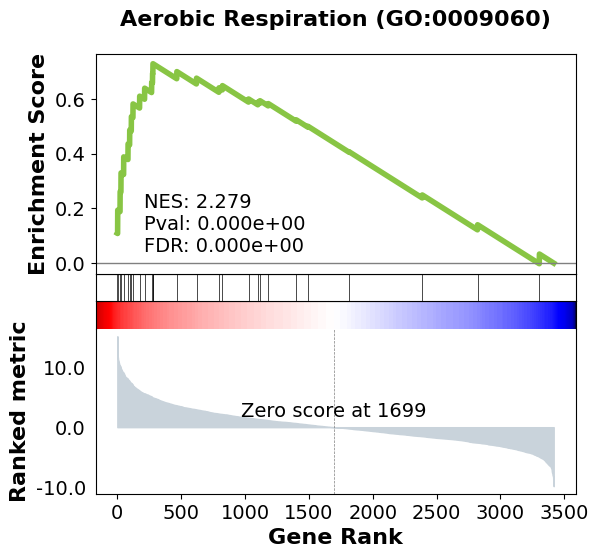

In [ ]:

term_to_graph = out_df.iloc[0]['Term']


result = pre_res.results[term_to_graph]

gseapy.gseaplot(
    rank_metric=pre_res.ranking,
    term=term_to_graph,
    hits=result['hits'],
    nes=result['nes'],
    pval=result['pval'],
    fdr=result['fdr'],
    RES=result['RES'],
)

### Plot barplot/dotplot for enrichment test

<Axes: xlabel='fdr'>

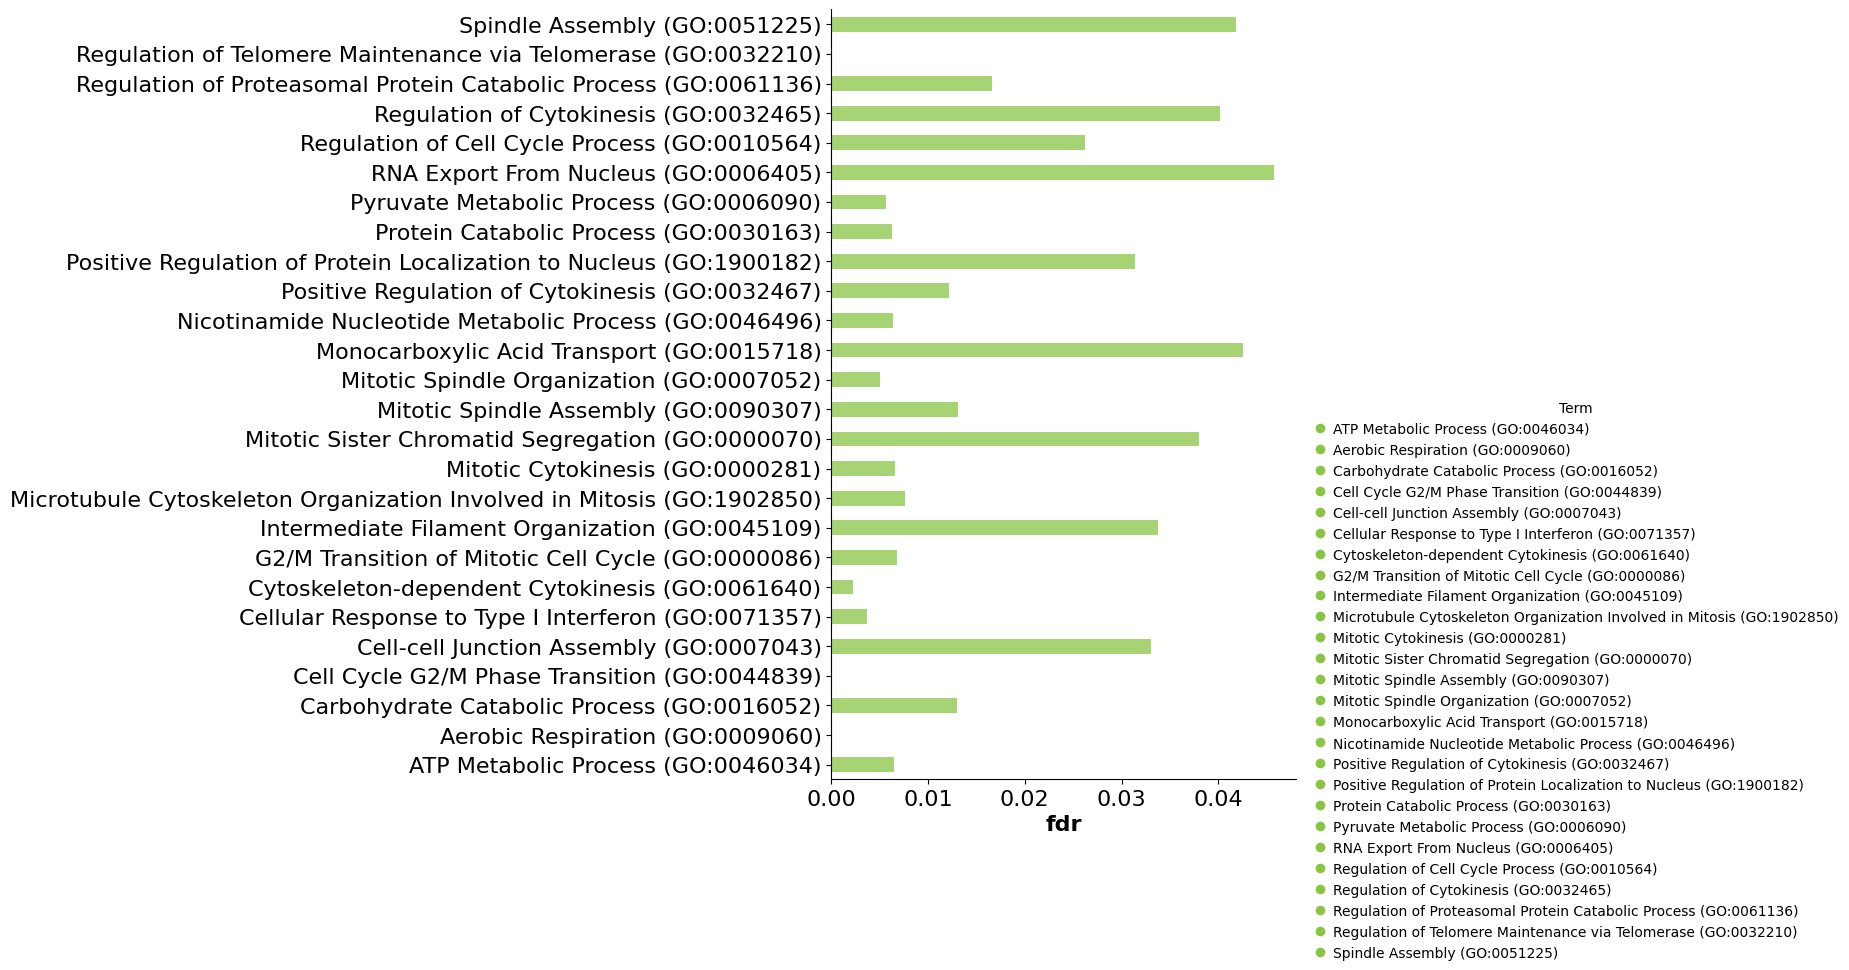

In [141]:
from gseapy import barplot

barplot(
    df=out_df,           # your enrichment results dataframe
    column='fdr',  # column to colour by
    group='Term',
    color='#88C544',
    figsize=(6, 10),
    ofname=None          # set a path to save
)

<Axes: title={'center': 'GSEA'}, xlabel='nes'>

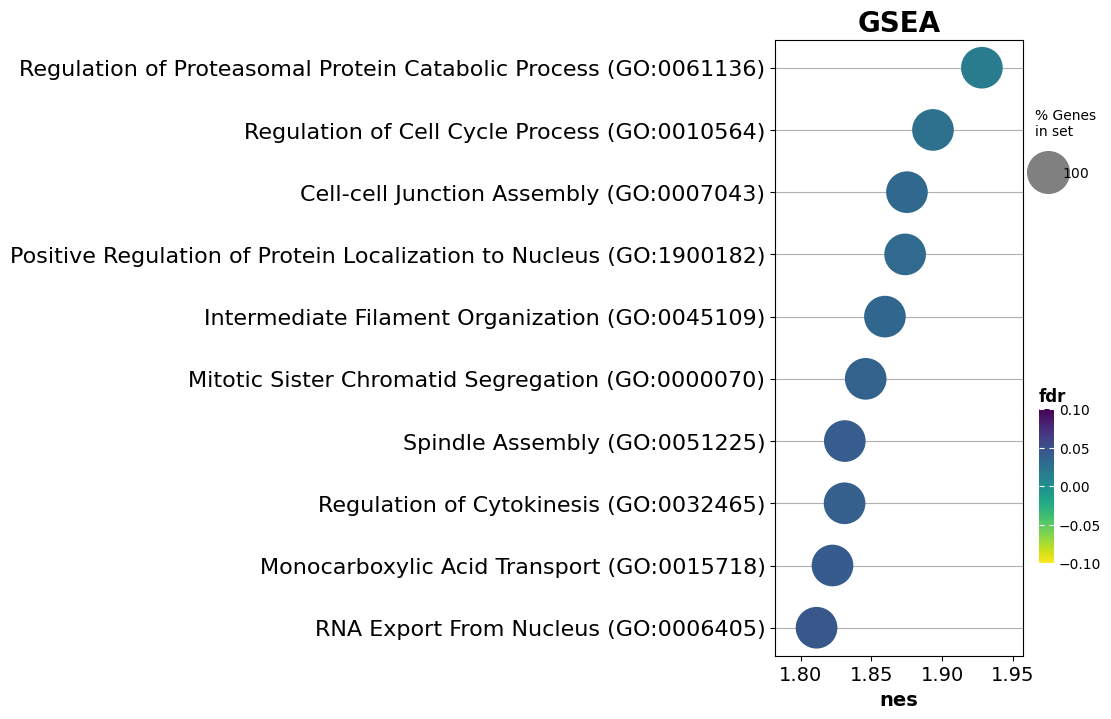

In [140]:
from gseapy import dotplot

dotplot(
    df=out_df,
    column='fdr',
    x='nes',
    title='GSEA',
    figsize=(4, 8),
    cutoff=0.05
)

## Plotting a clustermap of DExped genes --> again, not strictly YAP1 analysis, but may be interesting

In [116]:
import numpy as np
import seaborn as sns

In [ ]:
dds.layers['log1p'] = np.log1p(dds.layers['normed_counts']) #log1p your normalised counts from your deseq dataset object
dds

AnnData object with n_obs × n_vars = 30 × 5056
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'psbulk_cells', 'psbulk_counts', 'size_factors', 'replaceable'
    var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression', '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [118]:
#filter dds by your sigs 
dds_sigs = dds[:, sigs.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 30 × 423
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'psbulk_cells', 'psbulk_counts', 'size_factors', 'replaceable'
    var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression', '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [120]:
grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                       index = dds_sigs.var_names, columns = dds_sigs.obs_names)

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


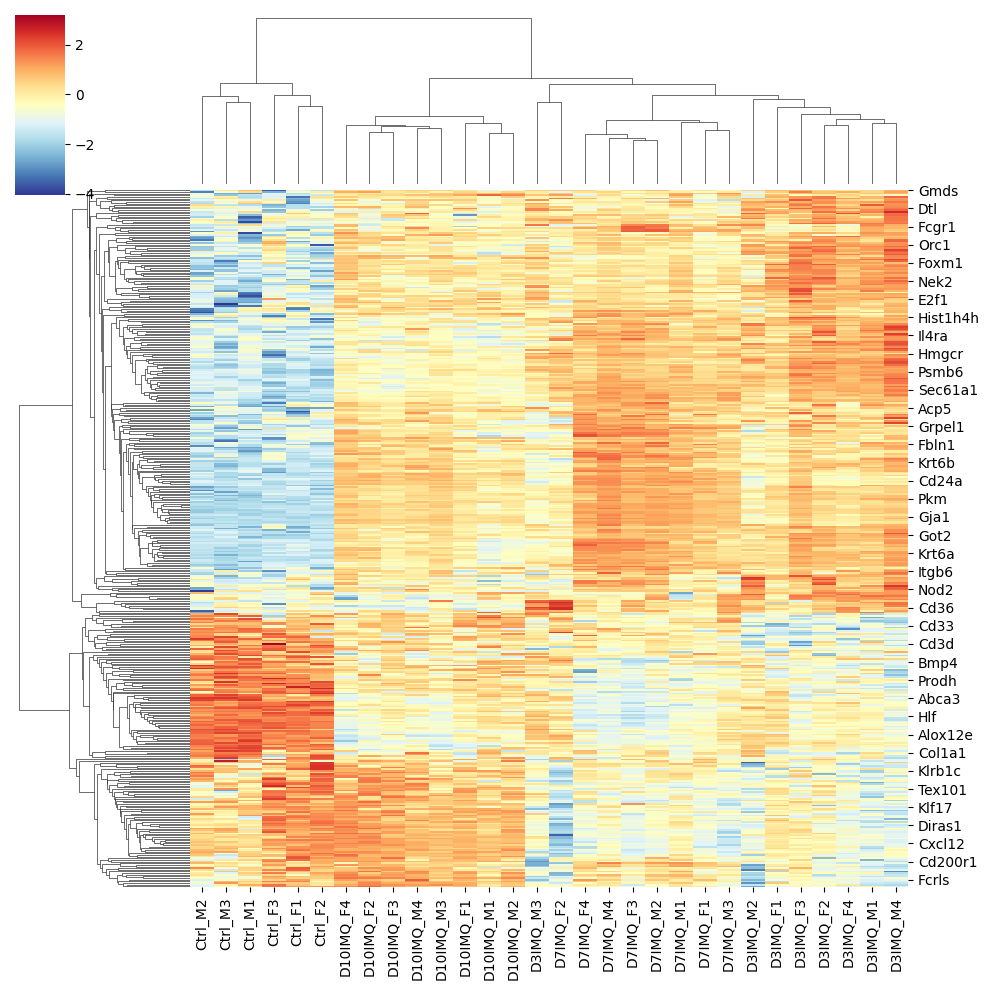

In [122]:
sns.clustermap(grapher, z_score = 0, cmap = 'RdYlBu_r')

# DESEQ between activated and non-activated conditions

In [1]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
adata

#only considering dorsal epi/dermis
adata = adata[adata.obs['compartment'].str.contains('orsal')]
adata.obs.compartment.unique()

['dorsal_dermis', 'dorsal_epidermis']
Categories (2, object): ['dorsal_dermis', 'dorsal_epidermis']

In [22]:
#bulk
import decoupler as dc

adata_epi = adata[adata.obs['compartment'].str.contains('_epidermis')].copy()
adata_derm = adata[adata.obs['compartment'].str.contains('_dermis')].copy()

#convert sc object to pseudobulk
celltype_bulk = dc.pp.pseudobulk(
    adata,
    sample_col = 'batch_key', #defines replicates
    groups_col = 'celltype_assignments', #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)
celltype_bulk.obs

,batch_key,celltype_assignments,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,region,z_level,replicate,condition,_scvi_batch,_scvi_labels,highlight,sex,psbulk_cells,psbulk_counts
Ctrl_F1_M2-like_macrophage,Ctrl_F1,M2-like_macrophage,0,0,0,0,cell_labels,0.0,F1,Ctrl,0,0,NaN,F,65.0,2482.0
Ctrl_F2_M2-like_macrophage,Ctrl_F2,M2-like_macrophage,0,0,0,0,cell_labels,0.0,F2,Ctrl,1,0,NaN,F,39.0,1015.0
Ctrl_F3_M2-like_macrophage,Ctrl_F3,M2-like_macrophage,0,0,0,0,cell_labels,0.0,F3,Ctrl,2,0,NaN,F,38.0,946.0
Ctrl_M1_M2-like_macrophage,Ctrl_M1,M2-like_macrophage,0,0,0,0,cell_labels,0.0,M1,Ctrl,3,0,NaN,M,84.0,2851.0
Ctrl_M2_M2-like_macrophage,Ctrl_M2,M2-like_macrophage,0,0,0,0,cell_labels,0.0,M2,Ctrl,4,0,NaN,M,84.0,2899.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D7IMQ_F4_suprabasal_KC,D7IMQ_F4,suprabasal_KC,0,0,0,0,cell_labels,0.0,F4,D7IMQ,17,0,NaN,F,0.0,0.0
D7IMQ_M1_suprabasal_KC,D7IMQ_M1,suprabasal_KC,0,0,0,0,cell_labels,0.0,M1,D7IMQ,18,0,NaN,M,18.0,7552.0
D7IMQ_M2_suprabasal_KC,D7IMQ_M2,suprabasal_KC,0,0,0,0,cell_labels,0.0,M2,D7IMQ,19,0,NaN,M,0.0,0.0
D7IMQ_M3_suprabasal_KC,D7IMQ_M3,suprabasal_KC,0,0,0,0,cell_labels,0.0,M3,D7IMQ,20,0,NaN,M,98.0,57702.0


In [4]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd
import numpy as np
import seaborn as sns
import gseapy as gp
from gseapy import gseaplot

from pathlib import Path
results_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\DESEQ_bulk_D3_D7_results")

In [24]:
single_bulk = celltype_bulk[(celltype_bulk.obs['celltype_assignments'] == 'activated_basal_KC') | (celltype_bulk.obs['celltype_assignments'] == 'basal_KC')]
dds = DeseqDataSet(counts = single_bulk.X,
                metadata = single_bulk.obs,
                design_factors = ['condition', 'celltype_assignments'])
dds.var = single_bulk.var
dds.obs.head(3)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_25412\1120068800.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts = single_bulk.X,


,batch_key,celltype_assignments,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,region,z_level,replicate,condition,_scvi_batch,_scvi_labels,highlight,sex,psbulk_cells,psbulk_counts
Ctrl_F1_activated_basal_KC,Ctrl_F1,activated_basal_KC,0,0,0,0,cell_labels,0.0,F1,Ctrl,0,0,NaN,F,10.0,392.0
Ctrl_F2_activated_basal_KC,Ctrl_F2,activated_basal_KC,0,0,0,0,cell_labels,0.0,F2,Ctrl,1,0,NaN,F,16.0,979.0
Ctrl_F3_activated_basal_KC,Ctrl_F3,activated_basal_KC,0,0,0,0,cell_labels,0.0,F3,Ctrl,2,0,NaN,F,8.0,265.0


In [26]:
dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


KeyboardInterrupt: 

In [ ]:
stat_res = DeseqStats(dds, contrast = ['celltype_assignments', 'activated_basal_KC', 'basal_KC'])